In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D
from copy import deepcopy
import torch 
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import os
import time
import gc
import scipy
from scipy.signal import butter, filtfilt, argrelextrema
from scipy.interpolate import interp1d
from mup import MuReadout, MuSGD, MuAdam
import mup as mup

In [2]:

# improve the ploting style
rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 22
rcParams['mathtext.fontset'] = 'stix'

In [3]:
dtype = torch.float32

# if torch.backends.mps.is_available():
#     device = torch.device("mps")
# else :
device = torch.device("cpu")
print("Computing on : ", device)


def generate_weights(d, k, epsilon):
    '''Generates the teacher W1 matrix and the a final vector'''
    deff = int(d**epsilon)      # d**epsilon est la dimension de la premiere feature map utile du jeu de donnees
    W1_stars = [0]*k            # k est le nombre d'index
    ws = [torch.sign(torch.randn(deff, 1, dtype=dtype)) for _ in range(k)] # ws est un tuple (deff,k) qui contient la matrice de projection finale pour chaque indice
    random_matrix,_ = np.linalg.qr(np.random.randn(d, k*deff))  # One generates the coefficients for the different index W1*_i matrices
    for i in range(k):
        W1_stars[i] = random_matrix[:, i*deff:(i+1)*deff]   # One generates the W1*_i matrix coefficients for the each index and put it in a tuple
        W1_stars[i] = torch.tensor(W1_stars[i], dtype=dtype).to(device)
    return W1_stars, ws

def generate_data(W1_stars, ws, n, d, epsilon, k, sigma_star1, sigma_star2):
    deff = int(d**epsilon)
    x = torch.randn(n, d).to(device).to(dtype)  # Generates n gaussian data points
    hs = torch.zeros(n, k).to(device).to(dtype) # Generates a support tensor for the index of each data
    for i in range(k):
        "Generate non-linear features for every branch"
        w = ws[i].to(device).to(dtype)
        h2 = torch.mm(x, W1_stars[i])   # h2 = x.W1_i
        hs[:,i] = (1 / np.sqrt(deff)) * torch.squeeze(torch.mm(sigma_star1(h2),w)).to(device) # hs_i = (Polynome(h2_i).a_i)/sqrt(deff)
    " Commitee machine with sigma_star2 activation"
    y = 1/np.sqrt(k)*torch.sum(sigma_star2(hs), dim=1).unsqueeze(1).to(device).to(dtype) # y = sum_i(sigma(hs_i))/sqrt(k)
    return x, y, hs

def He_2(x):
    return x**2 - 1

def He_3(x):
    return x**3 - 3*x

def Heaviside(x):
    return (x > 0).to(dtype).to(device)

Computing on :  cpu


In [4]:
W1_stars, ws = generate_weights(d=100, k=1, epsilon=0.5)
x_train, y_train, hs_train = generate_data(W1_stars, ws, n=int(100**(2.5)), d=100, epsilon=0.5, k=1, sigma_star1=He_3, sigma_star2=Heaviside)
x_valid, y_valid, hs_valid = generate_data(W1_stars, ws, n=int(100**(2.5)), d=100, epsilon=0.5, k=1, sigma_star1=He_3, sigma_star2=Heaviside)


In [5]:
### BY HAND CONSTRUCTOR ###

dtype = torch.float32

if torch.backends.mps.is_available():
    device = torch.device("mps")
else :
    device = torch.device("cpu")
print("Computing on : ", device)

def ReLU(x):
    return torch.max(torch.tensor(0).to(device),x)

def ReLU_derivative(x):
    return (x>0).type(dtype).to(device)

def softmax_derivative(s):
    """
    s : Tensor de shape (n_batch, num_classes), déjà softmaxé
    Renvoie : Tensor de shape (n_batch, num_classes, num_classes) contenant la jacobienne de softmax pour chaque échantillon
    """
    s = s.to(device)
    n, C = s.shape
    jacobians = torch.zeros(n, C, C, dtype=s.dtype).to(device) # Initialisation du tenseur Jacobien (n_batch, num_classes, num_classes) => (i,j,k) = dérivée de softmax au logit j du ième batch par rapport au logit k du même batch
    for i in range(n):  # Pour chaque échantillon du batch, on calcule la jacobienne de softmax
        si = s[i].unsqueeze(1)  # shape (C, 1) # vecteur softmax(logits) pour la i-ème donnée du batch
        jacobians[i] = torch.diagflat(si) - torch.mm(si,si.t()) # calcul de la jacobienne (matrice des dérivées croisées) de softmax au point z_i = vect(logits_i) # shape (C, C) -> Indice du Jacobien : lignes, Indice des logits : colonnes
    return jacobians

def sigmoid(x):
    return 1/(1+torch.exp(-x))

def sigmoid_derivative(x):
    return torch.exp(-x)/((1 + torch.exp(-x))**2)

def tanh_derivative(x):
    return (1 - (torch.tanh(x)**2)).to(device)

class two_layer_NN(nn.Module):
    def __init__(self,input_dimension,hidden_1_size,number_of_classes,lr=1e-3, reg1 = 0, reg2 = 0, eps_init=1, fraction_batch=0.01, observation_rate = 100):
        """
        Constructor of the two-layer neural network class.
        """
        super(two_layer_NN,self).__init__()
        self.architecture = ""
        self.input_dimension = input_dimension
        self.hidden_1_size = hidden_1_size
        self.number_of_classes = number_of_classes
        self.lr = lr
        self.eps_init = eps_init
        self.reg1 = reg1
        self.reg2 = reg2
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        self.training_time = 0
        # Initializing layers and bias        
        self.W1 = torch.randn(hidden_1_size, input_dimension, dtype=dtype) / np.sqrt(input_dimension) # will lead to a sum over "input_dimension" coefficients, thus to normalise the norm, we divide by "input_dimension"
        self.W2 = self.eps_init*torch.randn(number_of_classes, hidden_1_size, dtype=dtype ) / np.sqrt(hidden_1_size)
        self.b1 = (2*torch.rand(hidden_1_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-1,1)
        self.b2 = eps_init*(2*torch.rand(number_of_classes,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-eps,eps) # on mutiplie par eps pour que les biais soient petits et ainsi éviter l'explosion ou le vanishing des gradients
        # Moving to device 
        self.W1 = self.W1.to(device)
        self.W2 = self.W2.to(device)
        self.b1 = self.b1.to(device)
        self.b2 = self.b2.to(device)
        # Initializing Softmax
        self.softmax = nn.Softmax(dim=1) # on applique la fonction softmax sur la dimension 1 (c'est à dire sur les classes) # dim=0 correspond à la dimension des batchs
        #Initializing losses and accuracies during training list
        self.validation_loss_trajectory = []
        self.training_loss_trajectory = []
        self.accuracy_trajectory = []
        # Activation = ReLU
        # Loss = 0.5*MSE
        # Optimizer = GD
        
    def forward(self, x):
        z1 = (torch.mm(self.W1, x.t()) + self.b1).t() # shape (n_data, hidden_1_size) # logits layer 1
        h1 = ReLU(z1)  # hidden neurons layer 1
        z2 = (torch.mm(self.W2, h1.t()) + self.b2).t() # shape (n_data, number_of_classes ) # logits layer 2
        output = self.softmax(z2) # output layer # shape (n_data, number_of_classes)
        return output, z2, h1, z1
    
    # coef_iter est a ajusté en fonction du seuil kappa_eff d'apprentissage des données.
    def train_layers(self, x_train, y_train, x_valid, y_valid, kappa = 2, lr=1e-3, reg1=0, reg2=0, eps_init=1, fraction_batch=0.01, observation_rate = 100, train_layer_1 = True, train_layer_2 = True):
        # Initializing the training chronometer
        start = time.time()
        unwanted_time = 0
        # Initializing training parameters
        self.architecture = "2 layers" + " - Training first layer : " + str(train_layer_1) + " - Training second layer : " + str(train_layer_2) + " - kappa = " + str(kappa) + " - lr = " + str(lr) + " - reg1 = " + str(reg1) + " - reg2 = " + str(reg2) + " - eps_init = " + str(eps_init) + " - fraction_batch = " + str(fraction_batch) 
        self.lr = lr
        self.reg1 = reg1
        self.reg2 = reg2
        self.eps_init = eps_init
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        # Initializing the number of training iterations 
        N_datas = self.input_dimension**(kappa)/self.fraction_batch # Number of datas that we want to use for the training
        minibatch_size = int(x_train.shape[0]*self.fraction_batch)
        N_iterations = int(N_datas/minibatch_size)
        print(f"For kappa = {kappa}, the number of datas used for the training is {N_datas} and the number of iterations is {N_iterations}.")
        # Moving training and validation datas to device
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        x_valid = x_valid.to(device)
        y_valid = y_valid.to(device)
        
        for i in range(N_iterations):
            # Sélection un lot de données aléatoires parmis les données d'entrainement 
            indices_minibatch = torch.randperm(x_train.shape[0])[:minibatch_size]
            x_minibatch, y_minibatch = x_train[indices_minibatch], y_train[indices_minibatch] 
            # Calcul de la prédiction
            output, z2, h1, z1 = self.forward(x_minibatch)
            
            # Suivi de l'apprentissage # l'échantillonnage dépend d'observation_rate
            if i % self.observation_rate == 0:    
                unwanted_time_begin = time.time() # Pour soustraire le temps lié à la sauvegarde des données d'apprentissage au temps d'entrainement
                # Calcul des losses et de l'accuracy et ajout aux trajectoires
                training_loss = torch.mean(0.5*(output - y_minibatch)**2) # shape (number_of_classes, 1) # on divise par le nombre d'échantillons du minibatch pour obtenir la moyenne empirique de la loss
                validation_loss = torch.mean(0.5*(self.forward(x_valid)[0] - y_valid)**2)
                self.training_loss_trajectory.append(training_loss.item())
                self.validation_loss_trajectory.append(validation_loss.item())
                accuracy = torch.mean((torch.argmax(self.forward(x_valid)[0], dim=1) == torch.argmax(y_valid, dim=1)).to(dtype))
                self.accuracy_trajectory.append(accuracy.item())
                print("Iteration", i, "Training loss", training_loss.item(), "Validation loss", validation_loss.item(), "Accuracy", accuracy.item())
                # Soustraction du temps de sauvegarde
                unwanted_time += time.time() - unwanted_time_begin 
                
            # Loss = 0.5*(output - y_batch)**2 + reg1*||W1||**2 + reg1*||b1||**2 + reg2*||W2||**2 + reg2*||b2||**2 # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1)
            
            # Calcul des gradients
            grad_output = output - y_minibatch; grad_output = grad_output.to(dtype)
            grad_z2 = torch.einsum('noz, no->nz', softmax_derivative(output), grad_output); grad_z2  = grad_z2.to(dtype) # shape(n_data, num_classes) # produit du gradient de la loss par rapport aux outputs shape(n_data, num_classes) et du tenseur des Jacobiennes des outputs (n_data, num_classes, num_classes) # On multiplie la dimension des outputs (=dL/dy_i) du gradient avec la dimensions des outputs de la jacobienne (=dy_i/dz_j) pour obtenir le grad_z2 (dL(y_i)/dy_i)*(dy_i/dz_j)
            grad_h1 = torch.mm(grad_z2, self.W2); grad_h1  = grad_h1.to(dtype)  # shape (n_data, hidden_1_size)
            grad_z1 = grad_h1*ReLU_derivative(z1); grad_z1  = grad_z1.to(dtype) # shape (n_data, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/dW1 par backpropagation
            grad_W1 = (torch.mm(grad_z1.t(), x_minibatch)/x_minibatch.shape[0]).to(dtype) # shape (hidden_1_size, input_dimension)
            # Calcul de la moyenne empirique de dLoss/db1 par backpropagation
            grad_b1 = (torch.mean(grad_z1, dim=0).unsqueeze(1)).to(dtype) 
            # Calcul de la moyenne empirique de dLoss/dW2 par backpropagation
            grad_W2 = (torch.mm(grad_z2.t(), h1)/x_minibatch.shape[0]).to(dtype) # shape (number_of_classes, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/db2 par backpropagation
            grad_b2 = (torch.mean(grad_z2, dim=0).unsqueeze(1)).to(dtype)
            
            # Mise à jours des paramètres de la première couche
            if train_layer_1:
                self.W1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_W1/(self.eps_init**2) + self.reg1*self.W1)).to(dtype) # on multiplie par (hidden_1_size)**2 pour compenser la dilution du gradient avec l'augmentation de la taille de la couche de neurone (correction de la variance) # on divise par eps^2 pour compenser la faible amplitude des couches suivantes (Réajustement d'échelle) # on pénalise l'augmentation de la norme des poids de W1
                self.b1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_b1/(self.eps_init**2) + self.reg1*self.b1)).to(dtype)
            if train_layer_2:
                self.W2 -= (self.lr*(torch.sqrt(torch.tensor(self.number_of_classes))*grad_W2/(self.eps_init**2) +self.reg2*self.W2)).to(dtype)
                self.b2 -= (self.lr*(torch.sqrt(torch.tensor(self.number_of_classes))*grad_b2/(self.eps_init**2) + self.reg2*self.b2)).to(dtype)
            del x_minibatch, y_minibatch, output, z2, h1, z1, grad_output, grad_z2, grad_h1, grad_z1, grad_W1, grad_b1, grad_W2, grad_b2
            gc.collect()
        
        # Calcul de la durée de l'entraînement    
        self.training_time = time.time() - start - unwanted_time
        return "Training done"
   
class three_layer_NN(nn.Module):
    def __init__(self, input_dimension, hidden_1_size, hidden_2_size, number_of_classes,lr=0.01, reg1 =0, reg2 = 0, eps_init=1, fraction_batch=0.01, observation_rate = 10):
        """
        Constructor of the three-layer neural network class.
        """
        super(three_layer_NN,self).__init__()
        # Initialisation des propriétés du réseau
        self.architecture = ""
        self.input_dimension = input_dimension
        self.hidden_1_size = hidden_1_size
        self.hidden_2_size = hidden_2_size
        self.number_of_classes = number_of_classes
        self.lr = lr
        self.eps_init = eps_init
        self.reg1 = reg1
        self.reg2 = reg2
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        
        # Initialisation de la propriété durée d'entrainement
        self.training_time = 0
        
        # Initialisation des couches et des biais du réseau
        self.W1 = torch.randn(hidden_1_size, input_dimension, dtype=dtype) / np.sqrt(input_dimension) # will lead to a sum over "input_dimension" coefficients, thus to normalise the norm, we divide by "input_dimension"
        self.W2 = eps_init*torch.randn(hidden_2_size, hidden_1_size, dtype=dtype ) / np.sqrt(hidden_1_size)
        self.W3 = eps_init*torch.randn(number_of_classes, hidden_2_size, dtype=dtype)/np.sqrt(hidden_2_size)
        self.b1 = (2*torch.rand(hidden_1_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-1,1)
        self.b2 = eps_init*(2*torch.rand(hidden_2_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-eps,eps) # on mutiplie par eps pour que les biais soient petits et ainsi éviter l'explosion ou le vanishing des gradients
        self.b3 = eps_init*(2*torch.rand(number_of_classes,1,dtype=dtype)-1)
        
        # Moving to device 
        self.W1 = self.W1.to(device)
        self.W2 = self.W2.to(device)
        self.W3 = self.W3.to(device)
        self.b1 = self.b1.to(device)
        self.b2 = self.b2.to(device)
        self.b3 = self.b3.to(device)
        
        # Initializing Softmax
        self.softmax = nn.Softmax(dim=1) # on applique la fonction softmax sur la dimension 1 (c'est à dire sur les classes) # dim=0 correspond à la dimension des batchs
        
        #Initializing losses and accuracies during training list
        self.validation_loss_trajectory = []
        self.training_loss_trajectory = []
        self.accuracy_trajectory = []
        # Activation = ReLU
        # Loss = 0.5*MSE
        # Optimizer = GD
        
    def forward(self, x):
        z1 = (torch.mm(self.W1, x.t()) + self.b1).t() # shape (n_data, hidden_1_size) # logits layer 1
        h1 = ReLU(z1)  # hidden neurons layer 1
        z2 = (torch.mm(self.W2, h1.t()) + self.b2).t() # shape (n_data, number_of_classes ) # logits layer 2
        h2 = ReLU(z2) # hidden neurons layer 2
        z3 = (torch.mm(self.W3,h2.t()) + self.b3).t()
        output = self.softmax(z3) # output layer # shape (n_data, number_of_classes)
        return output, z3, h2, z2, h1, z1
    
    def train_layers(self, x_train, y_train, x_valid, y_valid, kappa = 2, lr=1e-3, reg1 = 0, reg2 = 0, reg3 = 0, eps_init=1, fraction_batch=0.01, observation_rate = 10, train_layer_1 = True, train_layer_2 = True, train_layer_3 = True):
        # Initializing training chronometer
        start = time.time()
        unwanted_time = 0
        # Initializing training parameters
        self.architecture = "3 layers" + " - Training first layer : " + str(train_layer_1) + " - Training second layer : " + str(train_layer_2) + " - Training third layer : " + str(train_layer_3) + " - kappa = " + str(kappa) + " - lr = " + str(lr) + " - reg1 = " + str(reg1) + " - reg2 = " + str(reg2) + " - eps_init = " + str(eps_init) + " - fraction_batch = " + str(fraction_batch)
        self.lr = lr
        self.reg1 = reg1
        self.reg2 = reg2
        self.reg3 = reg3
        self.eps_init = eps_init
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        # Moving input datas to device
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        x_valid = x_valid.to(device)
        y_valid = y_valid.to(device)        
        # Initializing the number of training iterations 
        N_datas = self.input_dimension**(kappa)/self.fraction_batch # Number of datas that we want to use for the training
        minibatch_size = int(x_train.shape[0]*self.fraction_batch)
        N_iterations = int(N_datas/minibatch_size)
        print(f"For kappa = {kappa}, the number of datas used for the training is {N_datas} and the number of iterations is {N_iterations}.")
        
        for i in range(N_iterations):
            
            # Tirage aléatoire d'un minibatch
            indices_minibatch = torch.randperm(x_train.shape[0])[:minibatch_size]
            x_minibatch, y_minibatch = x_train[indices_minibatch], y_train[indices_minibatch] # sélection un lot de données aléatoires parmis les données d'entrainement 
            
            # Calcul de la prédiction
            output, z3, h2, z2, h1, z1 = self.forward(x_minibatch)
            
            # Suivi de l'apprentissage # l'échantillonnage dépend d'observation_rate
            if i % self.observation_rate == 0:    
                unwanted_time_begin = time.time() # Pour soustraire le temps lié à la sauvegarde des données d'apprentissage au temps d'entrainement
                # Calcul des losses et de l'accuracy et ajout aux trajectoires
                training_loss = torch.mean(0.5*(output - y_minibatch)**2) # shape (number_of_classes, 1) # on divise par le nombre d'échantillons du minibatch pour obtenir la moyenne empirique de la loss
                validation_loss = torch.mean(0.5*(self.forward(x_valid)[0] - y_valid)**2)
                self.training_loss_trajectory.append(training_loss.item())
                self.validation_loss_trajectory.append(validation_loss.item())
                accuracy = torch.mean((torch.argmax(self.forward(x_valid)[0], dim=1) == torch.argmax(y_valid, dim=1)).to(dtype))
                self.accuracy_trajectory.append(accuracy.item())
                print("Iteration", i, "Training loss", training_loss.item(), "Validation loss", validation_loss.item(), "Accuracy", accuracy.item())
                # Soustraction du temps de sauvegarde
                unwanted_time += time.time() - unwanted_time_begin 
            
            # Loss = 0.5*(output - y_batch)**2 + reg1*||W1||**2 + reg1*||b1||**2 + reg2*||W2||**2 + reg2*||b2||**2 + reg3*(||W3||**2 + ||b3||**2) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1)
            
            # Calcul des gradients
            grad_output = (output - y_minibatch).to(dtype)
            grad_z3 = (torch.einsum('no,noz->nz',grad_output,softmax_derivative(output))).to(dtype) # shape (n_data, num_classes) # produit du gradient de la loss par rapport aux outputs shape(n_data, num_classes) et du tenseur des Jacobiennes des outputs (n_data, num_classes, num_classes) # On multiplie la dimension des outputs (=dL/dy_i) du gradient avec la dimensions des outputs de la jacobienne (=dy_i/dz_j) pour obtenir le grad_z2 (dL(y_i)/dy_i)*(dy_i/dz_j)
            grad_h2 = (torch.mm(grad_z3, self.W3)).to(dtype) # shape (n_data, hidden_2_size)
            grad_z2 = (grad_h2*ReLU_derivative(z2)).to(dtype) # shape(n_data, hidden_2_size)         
            grad_h1 = (torch.mm(grad_z2, self.W2)).to(dtype)  # shape (n_data, hidden_1_size)
            grad_z1 = (grad_h1*ReLU_derivative(z1)).to(dtype) # shape (n_data, hidden_1_size)
            
            # Calcul de la moyenne empirique de dLoss/dW1 par backpropagation
            grad_W1 = (torch.mm(grad_z1.t(), x_minibatch)/x_minibatch.shape[0]).to(dtype) # shape (hidden_1_size, input_dimension)
            # Calcul de la moyenne empirique de dLoss/db1 par backpropagation
            grad_b1 = (torch.mean(grad_z1, dim=0).unsqueeze(1)).to(dtype) 
            # Calcul de la moyenne empirique de dLoss/dW2 par backpropagation
            grad_W2 = (torch.mm(grad_z2.t(), h1)/x_minibatch.shape[0]).to(dtype) # shape (number_of_classes, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/db2 par backpropagation
            grad_b2 = (torch.mean(grad_z2, dim=0).unsqueeze(1)).to(dtype)
            # Calcul de la moyenne empirique de dLoss/dW3 par backpropagation
            grad_W3 = (torch.mm(grad_z3.t(),h2)/x_minibatch.shape[0]).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation
            grad_b3 = (torch.mean(grad_z3,dim=0).unsqueeze(1)).to(dtype)
            
            # Mise à jours des paramètres de la première couche
            if train_layer_1:
                self.W1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_W1/(self.eps_init**2) + self.reg1*self.W1)).to(dtype) # on multiplie par (hidden_1_size)**2 pour compenser la dilution du gradient avec l'augmentation de la taille de la couche de neurone (correction de la variance) # on divise par eps^2 pour compenser la faible amplitude des couches suivantes (Réajustement d'échelle) # on pénalise l'augmentation de la norme des poids de W1
                self.b1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_b1/(self.eps_init**2) + self.reg1*self.b1)).to(dtype)
            if train_layer_2:
                self.W2 -= (self.lr*(torch.sqrt(torch.tensor(self.number_of_classes))*grad_W2/(self.eps_init**2) +self.reg2*self.W2)).to(dtype)
                self.b2 -= (self.lr*(torch.sqrt(torch.tensor(self.number_of_classes))*grad_b2/(self.eps_init**2) + self.reg2*self.b2)).to(dtype)
            if train_layer_3:
                self.W3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_W3/(eps_init**2) + self.reg3*self.W3)).to(dtype)
                self.b3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_b3/(eps_init**2) + self.reg3*self.b3)).to(dtype)
            del x_minibatch, y_minibatch, output, z3, h2, z2, h1, z1, grad_output, grad_z3, grad_h2, grad_z2, grad_h1, grad_z1, grad_W1, grad_b1, grad_W2, grad_b2, grad_W3, grad_b3
            gc.collect()
        
        # Calcul de la durée d'entrainement
        self.training_time = time.time() - start - unwanted_time
        return "Training done"

class binary_classification_two_layer_NN(nn.Module):
    def __init__(self,input_dimension,hidden_1_size, lr=1e-3, lr_decay_rate = 1e9, reg1 = 0, reg2 = 0, eps_init=1, fraction_batch=0.01, observation_rate = 100):
        """
        Constructor of the two-layer neural network class.
        """
        super(binary_classification_two_layer_NN,self).__init__()
        self.architecture = ""
        self.input_dimension = input_dimension
        self.hidden_1_size = hidden_1_size
        self.lr = lr
        self.lr_decay_rate = lr_decay_rate
        self.eps_init = eps_init
        self.reg1 = reg1
        self.reg2 = reg2
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        self.training_time = 0
        # Initializing layers and bias        
        self.W1 = torch.randn(hidden_1_size, input_dimension, dtype=dtype) / np.sqrt(input_dimension) # will lead to a sum over "input_dimension" coefficients, thus to normalise the norm, we divide by "input_dimension"
        self.W2 = self.eps_init*torch.randn(1, hidden_1_size, dtype=dtype ) / np.sqrt(hidden_1_size)
        self.b1 = (2*torch.rand(hidden_1_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-1,1)
        self.b2 = eps_init*(2*torch.rand(1,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-eps,eps) # on mutiplie par eps pour que les biais soient petits et ainsi éviter l'explosion ou le vanishing des gradients
        # Moving to device 
        self.W1 = self.W1.to(device)
        self.W2 = self.W2.to(device)
        self.b1 = self.b1.to(device)
        self.b2 = self.b2.to(device)
        #Initializing losses and accuracies during training list
        self.validation_loss_trajectory = []
        self.training_loss_trajectory = []
        self.accuracy_trajectory = []
        # Activation = ReLU
        # Loss = 0.5*MSE
        # Optimizer = GD
        
    def forward(self, x, dropout_rate=0):
        if dropout_rate != 0 :    
            dropout_mask_1 = ((torch.rand((x.shape[0], self.hidden_1_size)) > dropout_rate).to(dtype)).to(device)
        else : 
            dropout_mask_1 = 1
        z1 = (torch.mm(self.W1, x.t()) + self.b1).t() # shape (n_data, hidden_1_size) # logits layer 1
        h1 = ReLU(z1)*dropout_mask_1/(1 - dropout_rate)  # hidden neurons layer 1
        z2 = (torch.mm(self.W2, h1.t()) + self.b2).t() # shape (n_data, number_of_classes ) # logits layer 2
        output = torch.sigmoid(z2) # output layer # shape (n_data, number_of_classes)
        return output, z2, h1, z1
    
    
    # coef_iter est a ajusté en fonction du seuil kappa_eff d'apprentissage des données.
    def train_layers(self, x_train, y_train, x_valid, y_valid, kappa = 2, lr=1e-3, lr_decay_rate = 1e9, reg1=0, reg2=0, eps_init=1, fraction_batch=0.01, observation_rate = 100, train_layer_1 = True, train_layer_2 = True, dropout_rate = 0):
        # Initializing the training chronometer
        start = time.time()
        unwanted_time = 0
        # Initializing training parameters
        self.architecture = "2 layers" + " - Training first layer : " + str(train_layer_1) + " - Training second layer : " + str(train_layer_2) + " - kappa = " + str(kappa) + " - lr = " + str(lr) + " - lr_decay_rate = " + str(lr_decay_rate) + " - reg1 = " + str(reg1) + " - reg2 = " + str(reg2) + " - eps_init = " + str(eps_init) + " - fraction_batch = " + str(fraction_batch) + ' - observation rate = ' + str(observation_rate) + ' - Train layer 1 = ' + str(train_layer_1) + ' - Train layer 2 = ' + str(train_layer_2) + ' - Dropout rate = ' + str(dropout_rate)
        self.lr = torch.tensor(lr)
        self.lr_decay_rate = torch.tensor(lr_decay_rate)
        self.reg1 = reg1
        self.reg2 = reg2
        self.eps_init = eps_init
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        # Initializing the number of training iterations 
        N_datas = self.input_dimension**(kappa)/self.fraction_batch # Number of datas that we want to use for the training
        minibatch_size = int(x_train.shape[0]*self.fraction_batch)
        N_iterations = int(N_datas/minibatch_size)
        print(f"For kappa = {kappa}, the number of datas used for the training is {N_datas} and the number of iterations is {N_iterations}.")
        # Moving training and validation datas to device
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        x_valid = x_valid.to(device)
        y_valid = y_valid.to(device)
        
        for i in range(N_iterations):
            
            # Sélection un lot de données aléatoires parmis les données d'entrainement 
            indices_minibatch = torch.randperm(x_train.shape[0])[:minibatch_size]
            x_minibatch, y_minibatch = x_train[indices_minibatch], y_train[indices_minibatch] 
            
            # Calcul de la prédiction
            output, z2, h1, z1 = self.forward(x_minibatch, dropout_rate)
            
            # Suivi de l'apprentissage # l'échantillonnage dépend d'observation_rate
            if i % self.observation_rate == 0:    
                unwanted_time_begin = time.time() # Pour soustraire le temps lié à la sauvegarde des données d'apprentissage au temps d'entrainement
                # Calcul des losses et de l'accuracy et ajout aux trajectoires
                print("Output", output[20:22])
                training_loss = torch.mean(0.5*(output - y_minibatch)**2)
                validation_loss = torch.mean(0.5*(self.forward(x_valid)[0] - y_valid)**2)
                self.training_loss_trajectory.append(training_loss.item())
                self.validation_loss_trajectory.append(validation_loss.item())
                accuracy = torch.mean(((self.forward(x_valid)[0] > 0.5).to(dtype) == y_valid).to(dtype))
                self.accuracy_trajectory.append(accuracy.item())
                print("Iteration", i, "Training loss", training_loss.item(), "Validation loss", validation_loss.item(), "Accuracy", accuracy.item())
                # Soustraction du temps de sauvegarde
                unwanted_time += time.time() - unwanted_time_begin 
                
            # Loss = 0.5*(output - y_batch)**2 + reg1*||W1||**2 + reg1*||b1||**2 + reg2*||W2||**2 + reg2*||b2||**2 # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1)
            
            # Calcul des gradients
            grad_output = output - y_minibatch; grad_output = grad_output.to(dtype)
            grad_z2 = grad_output*sigmoid_derivative(z2); grad_z2  = grad_z2.to(dtype) # shape(n_data, 1)
            grad_h1 = torch.mm(grad_z2, self.W2); grad_h1  = grad_h1.to(dtype)  # shape (n_data, hidden_1_size)
            grad_z1 = grad_h1*ReLU_derivative(z1); grad_z1  = grad_z1.to(dtype) # shape (n_data, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/dW1 par backpropagation
            grad_W1 = (torch.mm(grad_z1.t(), x_minibatch)/x_minibatch.shape[0]).to(dtype) # shape (hidden_1_size, input_dimension)
            # Calcul de la moyenne empirique de dLoss/db1 par backpropagation
            grad_b1 = (torch.mean(grad_z1, dim=0).unsqueeze(1)).to(dtype) 
            # Calcul de la moyenne empirique de dLoss/dW2 par backpropagation
            grad_W2 = (torch.mm(grad_z2.t(), h1)/x_minibatch.shape[0]).to(dtype) # shape (number_of_classes, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/db2 par backpropagation
            grad_b2 = (torch.mean(grad_z2, dim=0).unsqueeze(1)).to(dtype)
            
            # if i == 250:
            #     break

            # Mise à jours des paramètres de la première couche
            if train_layer_1:
                self.W1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_W1/(self.eps_init**2) + self.reg1*self.W1)).to(dtype) # on multiplie par (hidden_1_size)**2 pour compenser la dilution du gradient avec l'augmentation de la taille de la couche de neurone (correction de la variance) # on divise par eps^2 pour compenser la faible amplitude des couches suivantes (Réajustement d'échelle) # on pénalise l'augmentation de la norme des poids de W1
                self.b1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_b1/(self.eps_init**2) + self.reg1*self.b1)).to(dtype)
            if train_layer_2:
                self.W2 -= (self.lr*(grad_W2/(self.eps_init**2) +self.reg2*self.W2)).to(dtype)
                self.b2 -= (self.lr*(grad_b2/(self.eps_init**2) + self.reg2*self.b2)).to(dtype)
            del x_minibatch, y_minibatch, output, z2, h1, z1, grad_output, grad_z2, grad_h1, grad_z1, grad_W1, grad_b1, grad_W2, grad_b2
            gc.collect()
            
            # Learning rate decay
            self.lr = lr*torch.exp(torch.tensor(-i/self.lr_decay_rate))
        
        # Calcul de la durée de l'entraînement    
        self.training_time = time.time() - start - unwanted_time
        return "Training done"
    
class binary_classification_three_layer_NN(nn.Module):
    def __init__(self, input_dimension, hidden_1_size, hidden_2_size, lr=0.01, lr_decay_rate = 1e9, reg1 =0, reg2 = 0, eps_init=1, fraction_batch=0.01, observation_rate = 10, dropout_rate = 0):
        """
        Constructor of the three-layer neural network class.
        """
        super(binary_classification_three_layer_NN,self).__init__()
        # Initialisation des propriétés du réseau
        self.architecture = ""
        self.input_dimension = input_dimension
        self.hidden_1_size = hidden_1_size
        self.hidden_2_size = hidden_2_size
        self.lr = lr
        self.lr_decay_rate = lr_decay_rate
        self.eps_init = eps_init
        self.reg1 = reg1
        self.reg2 = reg2
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        
        # Initialisation de la propriété durée d'entrainement
        self.training_time = 0
        
        # Initialisation des couches et des biais du réseau
        self.W1 = torch.randn(hidden_1_size, input_dimension, dtype=dtype) / np.sqrt(input_dimension) # will lead to a sum over "input_dimension" coefficients, thus to normalise the norm, we divide by "input_dimension"
        self.W2 = eps_init*torch.randn(hidden_2_size, hidden_1_size, dtype=dtype ) / np.sqrt(hidden_1_size)
        self.W3 = eps_init*torch.randn(1, hidden_2_size, dtype=dtype)/np.sqrt(hidden_2_size)
        self.b1 = (2*torch.rand(hidden_1_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-1,1)
        self.b2 = eps_init*(2*torch.rand(hidden_2_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-eps,eps) # on mutiplie par eps pour que les biais soient petits et ainsi éviter l'explosion ou le vanishing des gradients
        self.b3 = eps_init*(2*torch.rand(1,1,dtype=dtype)-1)
        
        # Moving to device 
        self.W1 = self.W1.to(device)
        self.W2 = self.W2.to(device)
        self.W3 = self.W3.to(device)
        self.b1 = self.b1.to(device)
        self.b2 = self.b2.to(device)
        self.b3 = self.b3.to(device)
        
        # Initializing Softmax
        self.softmax = nn.Softmax(dim=1) # on applique la fonction softmax sur la dimension 1 (c'est à dire sur les classes) # dim=0 correspond à la dimension des batchs
        
        #Initializing losses and accuracies during training list
        self.validation_loss_trajectory = []
        self.training_loss_trajectory = []
        self.accuracy_trajectory = []
        # Activation = ReLU
        # Loss = 0.5*MSE
        # Optimizer = GD
        
    def forward(self, x, dropout_rate=0):
        if dropout_rate != 0 :    
            dropout_mask_1 = ((torch.rand((x.shape[0], self.hidden_1_size)) > dropout_rate).to(dtype)).to(device)
            dropout_mask_2 = ((torch.rand((x.shape[0], self.hidden_2_size)) > dropout_rate).to(dtype)).to(device)
        else : 
            dropout_mask_1, dropout_mask_2 = 1, 1
        z1 = (torch.mm(self.W1, x.t()) + self.b1).t() # shape (n_data, hidden_1_size) # logits layer 1
        h1 = ReLU(z1)*dropout_mask_1  # hidden neurons layer 1
        z2 = (torch.mm(self.W2, h1.t()) + self.b2).t() # shape (n_data, hidden_2_size ) # logits layer 2
        h2 = ReLU(z2)*dropout_mask_2 # hidden neurons layer 2
        z3 = (torch.mm(self.W3,h2.t()) + self.b3).t() # shape (n_data, 1)
        output = sigmoid(z3) # output layer # shape (n_data, 1)
        return output, z3, h2, z2, h1, z1
    
    def train_layers(self, x_train, y_train, x_valid, y_valid, kappa = 2, lr=1e-3, lr_decay_rate = 1e9, reg1 = 0, reg2 = 0, reg3 = 0, eps_init=1, fraction_batch=0.01, observation_rate = 10, train_layer_1 = True, train_layer_2 = True, train_layer_3 = True, dropout_rate = 0):
        # Initializing training chronometer
        start = time.time()
        unwanted_time = 0
        # Initializing training parameters
        self.architecture = "3 layers" + " - Training first layer : " + str(train_layer_1) + " - Training second layer : " + str(train_layer_2) + " - Training third layer : " + str(train_layer_3) + " - kappa = " + str(kappa) + " - lr = " + str(lr) + " - lr_decay_rate " + str(lr_decay_rate) + " - reg1 = " + str(reg1) + " - reg2 = " + str(reg2) + " - eps_init = " + str(eps_init) + " - fraction_batch = " + str(fraction_batch)
        self.lr = torch.tensor(lr)
        self.decay_rate = lr_decay_rate
        self.reg1 = reg1
        self.reg2 = reg2
        self.reg3 = reg3
        self.eps_init = eps_init
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        # Moving input datas to device
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        x_valid = x_valid.to(device)
        y_valid = y_valid.to(device)        
        # Initializing the number of training iterations 
        N_datas = self.input_dimension**(kappa)/self.fraction_batch # Number of datas that we want to use for the training
        minibatch_size = int(x_train.shape[0]*self.fraction_batch)
        N_iterations = int(N_datas/minibatch_size)
        print(f"For kappa = {kappa}, the number of datas used for the training is {N_datas} and the number of iterations is {N_iterations}.")
        
        for i in range(N_iterations):
            
            # Tirage aléatoire d'un minibatch
            indices_minibatch = torch.randperm(x_train.shape[0])[:minibatch_size]
            x_minibatch, y_minibatch = x_train[indices_minibatch], y_train[indices_minibatch] # sélection un lot de données aléatoires parmis les données d'entrainement 
            
            # Dropout
            # dropout_mask = ((torch.rand((minibatch_size, x_train.shape[1])) > dropout_rate).to(dtype)).to(device)
            # x_minibatch = x_minibatch*dropout_mask
            
            # Calcul de la prédiction
            output, z3, h2, z2, h1, z1 = self.forward(x_minibatch, dropout_rate)
            
            # Suivi de l'apprentissage # l'échantillonnage dépend d'observation_rate
            if i % self.observation_rate == 0:    
                unwanted_time_begin = time.time() # Pour soustraire le temps lié à la sauvegarde des données d'apprentissage au temps d'entrainement
                # Calcul des losses et de l'accuracy et ajout aux trajectoires
                training_loss = torch.mean(0.5*(output - y_minibatch)**2) # shape (number_of_classes, 1) # on divise par le nombre d'échantillons du minibatch pour obtenir la moyenne empirique de la loss
                validation_loss = torch.mean(0.5*(self.forward(x_valid)[0] - y_valid)**2)
                self.training_loss_trajectory.append(training_loss.item())
                self.validation_loss_trajectory.append(validation_loss.item())
                accuracy = torch.mean(((self.forward(x_valid)[0] > 0.5).to(dtype) == y_valid).to(dtype))
                self.accuracy_trajectory.append(accuracy.item())
                print("Iteration", i, "Training loss", training_loss.item(), "Validation loss", validation_loss.item(), "Accuracy", accuracy.item())
                # Soustraction du temps de sauvegarde
                unwanted_time += time.time() - unwanted_time_begin 
            
            # Loss = 0.5*(output - y_batch)**2 + reg1*||W1||**2 + reg1*||b1||**2 + reg2*||W2||**2 + reg2*||b2||**2 + reg3*(||W3||**2 + ||b3||**2) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1)
            
            # Calcul des gradients
            grad_output = (output - y_minibatch).to(dtype)
            grad_z3 = grad_output*sigmoid_derivative(z3).to(dtype) # shape (n_data, 1) # produit du gradient de la loss par rapport aux outputs shape(n_data, num_classes) et du tenseur des Jacobiennes des outputs (n_data, num_classes, num_classes) # On multiplie la dimension des outputs (=dL/dy_i) du gradient avec la dimensions des outputs de la jacobienne (=dy_i/dz_j) pour obtenir le grad_z2 (dL(y_i)/dy_i)*(dy_i/dz_j)
            grad_h2 = (torch.mm(grad_z3, self.W3)).to(dtype) # shape (n_data, hidden_2_size)
            grad_z2 = (grad_h2*ReLU_derivative(z2)).to(dtype) # shape(n_data, hidden_2_size)         
            grad_h1 = (torch.mm(grad_z2, self.W2)).to(dtype)  # shape (n_data, hidden_1_size)
            grad_z1 = (grad_h1*ReLU_derivative(z1)).to(dtype) # shape (n_data, hidden_1_size)
            
            # Calcul de la moyenne empirique de dLoss/dW1 par backpropagation
            grad_W1 = (torch.mm(grad_z1.t(), x_minibatch)/x_minibatch.shape[0]).to(dtype) # shape (hidden_1_size, input_dimension)
            # Calcul de la moyenne empirique de dLoss/db1 par backpropagation
            grad_b1 = (torch.mean(grad_z1, dim=0).unsqueeze(1)).to(dtype) 
            # Calcul de la moyenne empirique de dLoss/dW2 par backpropagation
            grad_W2 = (torch.mm(grad_z2.t(), h1)/x_minibatch.shape[0]).to(dtype) # shape (number_of_classes, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/db2 par backpropagation
            grad_b2 = (torch.mean(grad_z2, dim=0).unsqueeze(1)).to(dtype)
            # Calcul de la moyenne empirique de dLoss/dW3 par backpropagation
            grad_W3 = (torch.mm(grad_z3.t(),h2)/x_minibatch.shape[0]).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation
            grad_b3 = (torch.mean(grad_z3,dim=0).unsqueeze(1)).to(dtype)
            
            # Mise à jours des paramètres de la première couche
            if train_layer_1:
                self.W1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_W1/(self.eps_init**2) + self.reg1*self.W1)).to(dtype) # on multiplie par (hidden_1_size)**2 pour compenser la dilution du gradient avec l'augmentation de la taille de la couche de neurone (correction de la variance) # on divise par eps^2 pour compenser la faible amplitude des couches suivantes (Réajustement d'échelle) # on pénalise l'augmentation de la norme des poids de W1
                self.b1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_b1/(self.eps_init**2) + self.reg1*self.b1)).to(dtype)
            if train_layer_2:
                self.W2 -= (self.lr*(grad_W2/(self.eps_init**2) +self.reg2*self.W2)).to(dtype)
                self.b2 -= (self.lr*(grad_b2/(self.eps_init**2) + self.reg2*self.b2)).to(dtype)
            if train_layer_3:
                self.W3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_W3/(eps_init**2) + self.reg3*self.W3)).to(dtype)
                self.b3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_b3/(eps_init**2) + self.reg3*self.b3)).to(dtype)
            del x_minibatch, y_minibatch, output, z3, h2, z2, h1, z1, grad_output, grad_z3, grad_h2, grad_z2, grad_h1, grad_z1, grad_W1, grad_b1, grad_W2, grad_b2, grad_W3, grad_b3
            gc.collect()
            
            # Learning rate decay
            self.lr = lr*torch.exp(torch.tensor(-i/self.lr_decay_rate))
            
            # if i == 12000:
            #     break
        
        # Calcul de la durée d'entrainement
        self.training_time = time.time() - start - unwanted_time
        return "Training done" 

class binary_classification_four_layer_NN(nn.Module):
    def __init__(self, input_dimension, hidden_1_size, hidden_2_size, hidden_3_size, lr=0.01, lr_decay_rate = 1e9, reg1 =0, reg2 = 0, reg3=0, eps_init=1, fraction_batch=0.01, observation_rate = 10, dropout_rate = 0):
        """
        Constructor of the four-layer neural network class.
        """
        super(binary_classification_four_layer_NN,self).__init__()
        # Initialisation des propriétés du réseau
        self.architecture = ""
        self.input_dimension = input_dimension
        self.hidden_1_size = hidden_1_size
        self.hidden_2_size = hidden_2_size
        self.hidden_3_size = hidden_3_size
        self.lr = lr
        self.lr_decay_rate = lr_decay_rate
        self.eps_init = eps_init
        self.reg1 = reg1
        self.reg2 = reg2
        self.reg3 = reg3
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        
        # Initialisation de la propriété durée d'entrainement
        self.training_time = 0
        
        # Initialisation des couches et des biais du réseau
        self.W1 = torch.randn(hidden_1_size, input_dimension, dtype=dtype) / np.sqrt(input_dimension) # will lead to a sum over "input_dimension" coefficients, thus to normalise the norm, we divide by "input_dimension"
        self.W2 = eps_init*torch.randn(hidden_2_size, hidden_1_size, dtype=dtype ) / np.sqrt(hidden_1_size)
        self.W3 = eps_init*torch.randn(hidden_3_size, hidden_2_size, dtype=dtype)/np.sqrt(hidden_2_size)
        self.W4 = eps_init*torch.randn(1, hidden_3_size, dtype = dtype) / np.sqrt(hidden_3_size)
        
        self.b1 = (2*torch.rand(hidden_1_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-1,1)
        self.b2 = eps_init*(2*torch.rand(hidden_2_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-eps,eps) # on mutiplie par eps pour que les biais soient petits et ainsi éviter l'explosion ou le vanishing des gradients
        self.b3 = eps_init*(2*torch.rand(hidden_3_size, 1, dtype=dtype)-1)
        self.b4 = eps_init*(2*torch.rand(1, 1, dtype = dtype)-1)
        
        # Moving to device 
        self.W1 = self.W1.to(device)
        self.W2 = self.W2.to(device)
        self.W3 = self.W3.to(device)
        self.W4 = self.W4.to(device)
        self.b1 = self.b1.to(device)
        self.b2 = self.b2.to(device)
        self.b3 = self.b3.to(device)
        self.b4 = self.b4.to(device)
        
        # Initializing Softmax
        self.softmax = nn.Softmax(dim=1) # on applique la fonction softmax sur la dimension 1 (c'est à dire sur les classes) # dim=0 correspond à la dimension des batchs
        
        #Initializing losses and accuracies during training list
        self.validation_loss_trajectory = []
        self.training_loss_trajectory = []
        self.accuracy_trajectory = []
        # Activation = ReLU
        # Loss = 0.5*MSE
        # Optimizer = GD
        
    def forward(self, x, dropout_rate=0):
        if dropout_rate != 0 :    
            dropout_mask_1 = ((torch.rand((x.shape[0], self.hidden_1_size)) > dropout_rate).to(dtype)).to(device)
            dropout_mask_2 = ((torch.rand((x.shape[0], self.hidden_2_size)) > dropout_rate).to(dtype)).to(device)
            dropout_mask_3 = ((torch.rand((x.shape[0], self.hidden_3_size)) > dropout_rate).to(dtype)).to(device)
        else : 
            dropout_mask_1, dropout_mask_2, dropout_mask_3 = 1, 1, 1
        z1 = (torch.mm(self.W1, x.t()) + self.b1).t() # shape (n_data, hidden_1_size) # logits layer 1
        h1 = ReLU(z1)*dropout_mask_1  # hidden neurons layer 1
        z2 = (torch.mm(self.W2, h1.t()) + self.b2).t() # shape (n_data, hidden_2_size ) # logits layer 2
        h2 = ReLU(z2)*dropout_mask_2 # hidden neurons layer 2
        z3 = (torch.mm(self.W3,h2.t()) + self.b3).t() # shape (n_data, hidden_3_size)
        h3 = ReLU(z3)*dropout_mask_3 # hidden neurons layer_3
        z4 = (torch.mm(self.W4, z3.t()) + self.b4).t() # shape (n_data,1)
        output = sigmoid(z4) # output layer # shape (n_data, 1)
        return output, z4, h3, z3, h2, z2, h1, z1
    
    def train_layers(self, x_train, y_train, x_valid, y_valid, kappa = 2, lr=1e-3, lr_decay_rate = 1e9, reg1 = 0, reg2 = 0, reg3 = 0, reg4 =0, eps_init=1, fraction_batch=0.01, observation_rate = 10, train_layer_1 = True, train_layer_2 = True, train_layer_3 = True, train_layer_4 = True, dropout_rate = 0):
        # Initializing training chronometer
        start = time.time()
        unwanted_time = 0
        # Initializing training parameters
        self.architecture = "3 layers" + " - Training first layer : " + str(train_layer_1) + " - Training second layer : " + str(train_layer_2) + " - Training third layer : " + str(train_layer_3) + " - Training fourth layer = " + str(train_layer_4) + " - kappa = " + str(kappa) + " - lr = " + str(lr) + " - lr_decay_rate " + str(lr_decay_rate) + " - reg1 = " + str(reg1) + " - reg2 = " + str(reg2) + " - eps_init = " + str(eps_init) + " - fraction_batch = " + str(fraction_batch) + " - dropout rate = " + str(dropout_rate)
        self.lr = torch.tensor(lr)
        self.decay_rate = lr_decay_rate
        self.reg1 = reg1
        self.reg2 = reg2
        self.reg3 = reg3
        self.reg4 = reg4
        self.eps_init = eps_init
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        # Moving input datas to device
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        x_valid = x_valid.to(device)
        y_valid = y_valid.to(device)        
        # Initializing the number of training iterations 
        N_datas = self.input_dimension**(kappa)/self.fraction_batch # Number of datas that we want to use for the training
        minibatch_size = int(x_train.shape[0]*self.fraction_batch)
        N_iterations = int(N_datas/minibatch_size)
        print(f"For kappa = {kappa}, the number of datas used for the training is {N_datas} and the number of iterations is {N_iterations}.")
        
        for i in range(N_iterations):
            
            # Tirage aléatoire d'un minibatch
            indices_minibatch = torch.randperm(x_train.shape[0])[:minibatch_size]
            x_minibatch, y_minibatch = x_train[indices_minibatch], y_train[indices_minibatch] # sélection un lot de données aléatoires parmis les données d'entrainement 
            
            # Dropout
            # dropout_mask = ((torch.rand((minibatch_size, x_train.shape[1])) > dropout_rate).to(dtype)).to(device)
            # x_minibatch = x_minibatch*dropout_mask
            
            # Calcul de la prédiction
            output, z4, h3, z3, h2, z2, h1, z1 = self.forward(x_minibatch, dropout_rate)
            
            # Suivi de l'apprentissage # l'échantillonnage dépend d'observation_rate
            if i % self.observation_rate == 0:    
                unwanted_time_begin = time.time() # Pour soustraire le temps lié à la sauvegarde des données d'apprentissage au temps d'entrainement
                # Calcul des losses et de l'accuracy et ajout aux trajectoires
                training_loss = torch.mean(0.5*(output - y_minibatch)**2) # shape (number_of_classes, 1) # on divise par le nombre d'échantillons du minibatch pour obtenir la moyenne empirique de la loss
                validation_loss = torch.mean(0.5*(self.forward(x_valid)[0] - y_valid)**2)
                self.training_loss_trajectory.append(training_loss.item())
                self.validation_loss_trajectory.append(validation_loss.item())
                accuracy = torch.mean(((self.forward(x_valid)[0] > 0.5).to(dtype) == y_valid).to(dtype))
                self.accuracy_trajectory.append(accuracy.item())
                print("Iteration", i, "Training loss", training_loss.item(), "Validation loss", validation_loss.item(), "Accuracy", accuracy.item())
                # Soustraction du temps de sauvegarde
                unwanted_time += time.time() - unwanted_time_begin 
            
            # Loss = 0.5*(output - y_batch)**2 + reg1*||W1||**2 + reg1*||b1||**2 + reg2*||W2||**2 + reg2*||b2||**2 + reg3*(||W3||**2 + ||b3||**2) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1)
            
            # Calcul des gradients
            grad_output = (output - y_minibatch).to(dtype)  # shape (n_data, 1)
            grad_z4 = grad_output*sigmoid_derivative(z4).to(dtype)  # shape (n_data, 1)
            grad_h3 = (torch.mm(grad_z4, self.W4)).to(dtype)  # shape (n_data, hidden_3_size)
            grad_z3 = grad_h3*sigmoid_derivative(z3).to(dtype) # shape (n_data, hidden_3_size) # produit du gradient de la loss par rapport aux outputs shape(n_data, num_classes) et du tenseur des Jacobiennes des outputs (n_data, num_classes, num_classes) # On multiplie la dimension des outputs (=dL/dy_i) du gradient avec la dimensions des outputs de la jacobienne (=dy_i/dz_j) pour obtenir le grad_z2 (dL(y_i)/dy_i)*(dy_i/dz_j)
            grad_h2 = (torch.mm(grad_z3, self.W3)).to(dtype) # shape (n_data, hidden_2_size)
            grad_z2 = (grad_h2*ReLU_derivative(z2)).to(dtype) # shape(n_data, hidden_2_size)         
            grad_h1 = (torch.mm(grad_z2, self.W2)).to(dtype)  # shape (n_data, hidden_1_size)
            grad_z1 = (grad_h1*ReLU_derivative(z1)).to(dtype) # shape (n_data, hidden_1_size)
            
            # Calcul de la moyenne empirique de dLoss/dW1 par backpropagation
            grad_W1 = (torch.mm(grad_z1.t(), x_minibatch)/x_minibatch.shape[0]).to(dtype) # shape (hidden_1_size, input_dimension)
            # Calcul de la moyenne empirique de dLoss/db1 par backpropagation
            grad_b1 = (torch.mean(grad_z1, dim=0).unsqueeze(1)).to(dtype) 
            # Calcul de la moyenne empirique de dLoss/dW2 par backpropagation
            grad_W2 = (torch.mm(grad_z2.t(), h1)/x_minibatch.shape[0]).to(dtype) # shape (number_of_classes, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/db2 par backpropagation
            grad_b2 = (torch.mean(grad_z2, dim=0).unsqueeze(1)).to(dtype)
            # Calcul de la moyenne empirique de dLoss/dW3 par backpropagation
            grad_W3 = (torch.mm(grad_z3.t(),h2)/x_minibatch.shape[0]).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation
            grad_b3 = (torch.mean(grad_z3,dim=0).unsqueeze(1)).to(dtype)
            
            grad_W4 = (torch.mm(grad_z4.t(),h3)/x_minibatch.shape[0]).to(dtype)
            
            grad_b4 = (torch.mean(grad_z4, dim=0).unsqueeze(1)).to(dtype)
            
            # Mise à jours des paramètres de la première couche
            if train_layer_1:
                self.W1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_W1/(self.eps_init**2) + self.reg1*self.W1)).to(dtype) # on multiplie par (hidden_1_size)**2 pour compenser la dilution du gradient avec l'augmentation de la taille de la couche de neurone (correction de la variance) # on divise par eps^2 pour compenser la faible amplitude des couches suivantes (Réajustement d'échelle) # on pénalise l'augmentation de la norme des poids de W1
                self.b1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_b1/(self.eps_init**2) + self.reg1*self.b1)).to(dtype)
            if train_layer_2:
                self.W2 -= (self.lr*(grad_W2/(self.eps_init**2) +self.reg2*self.W2)).to(dtype)
                self.b2 -= (self.lr*(grad_b2/(self.eps_init**2) + self.reg2*self.b2)).to(dtype)
            if train_layer_3:
                self.W3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_W3/(eps_init**2) + self.reg3*self.W3)).to(dtype)
                self.b3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_b3/(eps_init**2) + self.reg3*self.b3)).to(dtype)
            if train_layer_3:
                self.W3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_W3/(eps_init**2) + self.reg3*self.W3)).to(dtype)
                self.b3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_b3/(eps_init**2) + self.reg3*self.b3)).to(dtype)
            if train_layer_4:
                self.W4 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_3_size))*grad_W4/(eps_init**2) + self.reg4*self.W4)).to(dtype)
                self.b4 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_3_size))*grad_b4/(eps_init**2) + self.reg4*self.b4)).to(dtype)
            del x_minibatch, y_minibatch, output, z4, h3, z3, h2, z2, h1, z1, grad_output, grad_z4, grad_h3, grad_z3, grad_h2, grad_z2, grad_h1, grad_z1, grad_W1, grad_b1, grad_W2, grad_b2, grad_W3, grad_b3, grad_W4, grad_b4
            gc.collect()
            
            # Learning rate decay
            self.lr = lr*torch.exp(torch.tensor(-i/self.lr_decay_rate))
        
        # Calcul de la durée d'entrainement
        self.training_time = time.time() - start - unwanted_time
        return "Training done" 
    
    
class binary_classification_five_layer_NN(nn.Module):
    def __init__(self, input_dimension, hidden_1_size, hidden_2_size, hidden_3_size, hidden_4_size, lr=0.01, lr_decay_rate = 1e9, reg1=0, reg2=0, reg3=0, reg4=0, reg5=0, eps_init=1, fraction_batch=0.01, observation_rate = 10, dropout_rate = 0):
        """
        Constructor of the five-layer neural network class.
        """
        super(binary_classification_five_layer_NN,self).__init__()
        # Initialisation des propriétés du réseau
        self.architecture = ""
        self.input_dimension = input_dimension
        self.hidden_1_size = hidden_1_size
        self.hidden_2_size = hidden_2_size
        self.hidden_3_size = hidden_3_size
        self.hidden_4_size = hidden_4_size
        self.lr = lr
        self.lr_decay_rate = lr_decay_rate
        self.eps_init = eps_init
        self.reg1 = reg1
        self.reg2 = reg2
        self.reg3 = reg3
        self.reg4 = reg4
        self.reg5 = reg5
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        
        # Initialisation de la propriété durée d'entrainement
        self.training_time = 0
        
        # Initialisation des couches et des biais du réseau
        self.W1 = torch.randn(hidden_1_size, input_dimension, dtype=dtype) / np.sqrt(input_dimension) # will lead to a sum over "input_dimension" coefficients, thus to normalise the norm, we divide by "input_dimension"
        self.W2 = eps_init*torch.randn(hidden_2_size, hidden_1_size, dtype=dtype ) / np.sqrt(hidden_1_size)
        self.W3 = eps_init*torch.randn(hidden_3_size, hidden_2_size, dtype=dtype)/np.sqrt(hidden_2_size)
        self.W4 = eps_init*torch.randn(hidden_4_size, hidden_3_size, dtype = dtype) / np.sqrt(hidden_3_size)
        self.W5 = eps_init*torch.randn(1, hidden_4_size, dtype = dtype) / np.sqrt(hidden_4_size)
        
        self.b1 = (2*torch.rand(hidden_1_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-1,1)
        self.b2 = eps_init*(2*torch.rand(hidden_2_size,1,dtype=dtype)-1) # les biais sont initialisés aléatoirement selon une loi uniforme U(-eps,eps) # on mutiplie par eps pour que les biais soient petits et ainsi éviter l'explosion ou le vanishing des gradients
        self.b3 = eps_init*(2*torch.rand(hidden_3_size, 1, dtype=dtype)-1)
        self.b4 = eps_init*(2*torch.rand(hidden_4_size, 1, dtype = dtype)-1)
        self.b5 = eps_init*(2*torch.rand(1, 1, dtype = dtype)-1)
        
        # Moving to device 
        self.W1 = self.W1.to(device)
        self.W2 = self.W2.to(device)
        self.W3 = self.W3.to(device)
        self.W4 = self.W4.to(device)
        self.W5 = self.W5.to(device)

        self.b1 = self.b1.to(device)
        self.b2 = self.b2.to(device)
        self.b3 = self.b3.to(device)
        self.b4 = self.b4.to(device)
        self.b5 = self.b5.to(device)

        # Initializing Softmax
        self.softmax = nn.Softmax(dim=1) # on applique la fonction softmax sur la dimension 1 (c'est à dire sur les classes) # dim=0 correspond à la dimension des batchs
        
        #Initializing losses and accuracies during training list
        self.validation_loss_trajectory = []
        self.training_loss_trajectory = []
        self.accuracy_trajectory = []
        # Activation = ReLU
        # Loss = 0.5*MSE
        # Optimizer = GD
        
    def forward(self, x, dropout_rate=0):
        if dropout_rate != 0 :    
            dropout_mask_1 = ((torch.rand((x.shape[0], self.hidden_1_size)) > dropout_rate).to(dtype)).to(device)
            dropout_mask_2 = ((torch.rand((x.shape[0], self.hidden_2_size)) > dropout_rate).to(dtype)).to(device)
            dropout_mask_3 = ((torch.rand((x.shape[0], self.hidden_3_size)) > dropout_rate).to(dtype)).to(device)
            dropout_mask_4 = ((torch.rand((x.shape[0], self.hidden_4_size)) > dropout_rate).to(dtype)).to(device)
        else : 
            dropout_mask_1, dropout_mask_2, dropout_mask_3, dropout_mask_4 = 1, 1, 1, 1
        z1 = (torch.mm(self.W1, x.t()) + self.b1).t() # shape (n_data, hidden_1_size) # logits layer 1
        h1 = ReLU(z1)*dropout_mask_1  # hidden neurons layer 1
        z2 = (torch.mm(self.W2, h1.t()) + self.b2).t() # shape (n_data, hidden_2_size ) # logits layer 2
        h2 = ReLU(z2)*dropout_mask_2 # hidden neurons layer 2
        z3 = (torch.mm(self.W3,h2.t()) + self.b3).t() # shape (n_data, hidden_3_size)
        h3 = ReLU(z3)*dropout_mask_3 # hidden neurons layer_3
        z4 = (torch.mm(self.W4, z3.t()) + self.b4).t() # shape (n_data,1)
        h4 = ReLU(z4)*dropout_mask_4
        z5 = torch.mm(self.W5, h4.t() + self.b5).t()
        output = sigmoid(z5) # output layer # shape (n_data, 1)
        return output, z5, h4, z4, h3, z3, h2, z2, h1, z1
    
    def train_layers(self, x_train, y_train, x_valid, y_valid, kappa = 2, lr=1e-3, lr_decay_rate = 1e9, reg1 = 0, reg2 = 0, reg3 = 0, reg4 =0, reg5=0, eps_init=1, fraction_batch=0.01, observation_rate = 10, train_layer_1 = True, train_layer_2 = True, train_layer_3 = True, train_layer_4 = True, train_layer_5=True, dropout_rate = 0):
        # Initializing training chronometer
        start = time.time()
        unwanted_time = 0
        # Initializing training parameters
        self.architecture = "3 layers" + " - Training first layer : " + str(train_layer_1) + " - Training second layer : " + str(train_layer_2) + " - Training third layer : " + str(train_layer_3) + " - Training fourth layer = " + str(train_layer_4) + " - Training fifth layer = " + str(train_layer_5) + " - kappa = " + str(kappa) + " - lr = " + str(lr) + " - lr_decay_rate " + str(lr_decay_rate) + " - reg1 = " + str(reg1) + " - reg2 = " + str(reg2) + " - eps_init = " + str(eps_init) + " - fraction_batch = " + str(fraction_batch) + " - dropout rate = " + str(dropout_rate)
        self.lr = torch.tensor(lr)
        self.decay_rate = lr_decay_rate
        self.reg1 = reg1
        self.reg2 = reg2
        self.reg3 = reg3
        self.reg4 = reg4
        self.reg5 = reg5
        self.eps_init = eps_init
        self.fraction_batch = fraction_batch
        self.observation_rate = observation_rate
        # Moving input datas to device
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        x_valid = x_valid.to(device)
        y_valid = y_valid.to(device)        
        # Initializing the number of training iterations 
        N_datas = self.input_dimension**(kappa)/self.fraction_batch # Number of datas that we want to use for the training
        minibatch_size = int(x_train.shape[0]*self.fraction_batch)
        N_iterations = int(N_datas/minibatch_size)
        print(f"For kappa = {kappa}, the number of datas used for the training is {N_datas} and the number of iterations is {N_iterations}.")
        
        for i in range(N_iterations):
            
            # Tirage aléatoire d'un minibatch
            indices_minibatch = torch.randperm(x_train.shape[0])[:minibatch_size]
            x_minibatch, y_minibatch = x_train[indices_minibatch], y_train[indices_minibatch] # sélection un lot de données aléatoires parmis les données d'entrainement 
            
            # Dropout
            # dropout_mask = ((torch.rand((minibatch_size, x_train.shape[1])) > dropout_rate).to(dtype)).to(device)
            # x_minibatch = x_minibatch*dropout_mask
            
            # Calcul de la prédiction
            output, z5, h4, z4, h3, z3, h2, z2, h1, z1 = self.forward(x_minibatch, dropout_rate)
            
            # Suivi de l'apprentissage # l'échantillonnage dépend d'observation_rate
            if i % self.observation_rate == 0:    
                unwanted_time_begin = time.time() # Pour soustraire le temps lié à la sauvegarde des données d'apprentissage au temps d'entrainement
                # Calcul des losses et de l'accuracy et ajout aux trajectoires
                training_loss = torch.mean(0.5*(output - y_minibatch)**2) # shape (number_of_classes, 1) # on divise par le nombre d'échantillons du minibatch pour obtenir la moyenne empirique de la loss
                validation_loss = torch.mean(0.5*(self.forward(x_valid)[0] - y_valid)**2)
                self.training_loss_trajectory.append(training_loss.item())
                self.validation_loss_trajectory.append(validation_loss.item())
                accuracy = torch.mean(((self.forward(x_valid)[0] > 0.5).to(dtype) == y_valid).to(dtype))
                self.accuracy_trajectory.append(accuracy.item())
                print("Iteration", i, "Training loss", training_loss.item(), "Validation loss", validation_loss.item(), "Accuracy", accuracy.item())
                # Soustraction du temps de sauvegarde
                unwanted_time += time.time() - unwanted_time_begin 
            
            # Loss_tot = 0.5*(output - y_batch)**2 + reg1*||W1||**2 + reg1*||b1||**2 + reg2*||W2||**2 + reg2*||b2||**2 + reg3*(||W3||**2 + ||b3||**2) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1) # on ne pénalise pas les biais car ils sont déjà petits (initialisés aléatoirement entre -1 et 1)
            
            # Calcul des gradients
            grad_output = (output - y_minibatch).to(dtype)  # shape (n_data, 1)
            grad_z5 = grad_output*sigmoid_derivative(z5).to(dtype)  # shape (n_data, 1)
            grad_h4 = torch.mm(grad_z5, self.W5)    # shape (n_data, hidden_4_size)
            grad_z4 = grad_h4*ReLU_derivative(z4)   # shape (n_data, hidden_4_size)
            grad_h3 = (torch.mm(grad_z4, self.W4)).to(dtype)  # shape (n_data, hidden_3_size)
            grad_z3 = grad_h3*sigmoid_derivative(z3).to(dtype) # shape (n_data, hidden_3_size) # produit du gradient de la loss par rapport aux outputs shape(n_data, num_classes) et du tenseur des Jacobiennes des outputs (n_data, num_classes, num_classes) # On multiplie la dimension des outputs (=dL/dy_i) du gradient avec la dimensions des outputs de la jacobienne (=dy_i/dz_j) pour obtenir le grad_z2 (dL(y_i)/dy_i)*(dy_i/dz_j)
            grad_h2 = (torch.mm(grad_z3, self.W3)).to(dtype) # shape (n_data, hidden_2_size)
            grad_z2 = (grad_h2*ReLU_derivative(z2)).to(dtype) # shape(n_data, hidden_2_size)         
            grad_h1 = (torch.mm(grad_z2, self.W2)).to(dtype)  # shape (n_data, hidden_1_size)
            grad_z1 = (grad_h1*ReLU_derivative(z1)).to(dtype) # shape (n_data, hidden_1_size)
            
            # Calcul de la moyenne empirique de dLoss/dW1 par backpropagation
            grad_W1 = (torch.mm(grad_z1.t(), x_minibatch)/x_minibatch.shape[0]).to(dtype) # shape (hidden_1_size, input_dimension)
            # Calcul de la moyenne empirique de dLoss/db1 par backpropagation
            grad_b1 = (torch.mean(grad_z1, dim=0).unsqueeze(1)).to(dtype) 
            # Calcul de la moyenne empirique de dLoss/dW2 par backpropagation
            grad_W2 = (torch.mm(grad_z2.t(), h1)/x_minibatch.shape[0]).to(dtype) # shape (number_of_classes, hidden_1_size)
            # Calcul de la moyenne empirique de dLoss/db2 par backpropagation
            grad_b2 = (torch.mean(grad_z2, dim=0).unsqueeze(1)).to(dtype)
            # Calcul de la moyenne empirique de dLoss/dW3 par backpropagation
            grad_W3 = (torch.mm(grad_z3.t(),h2)/x_minibatch.shape[0]).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation
            grad_b3 = (torch.mean(grad_z3,dim=0).unsqueeze(1)).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation
            grad_W4 = (torch.mm(grad_z4.t(),h3)/x_minibatch.shape[0]).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation
            grad_b4 = (torch.mean(grad_z4, dim=0).unsqueeze(1)).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation            
            grad_W5 = (torch.mm(grad_z5.t(), h4)/x_minibatch.shape[0]).to(dtype)
            # Calcul de la moyenne empirique du gradient dLoss/db" par backpropagation
            grad_b5 = (torch.mean(grad_z5, dim=0)).to(dtype)
            
            # Mise à jours des paramètres de la première couche
            if train_layer_1:
                self.W1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_W1/(self.eps_init**2) + self.reg1*self.W1)).to(dtype) # on multiplie par (hidden_1_size)**2 pour compenser la dilution du gradient avec l'augmentation de la taille de la couche de neurone (correction de la variance) # on divise par eps^2 pour compenser la faible amplitude des couches suivantes (Réajustement d'échelle) # on pénalise l'augmentation de la norme des poids de W1
                self.b1 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_1_size))*grad_b1/(self.eps_init**2) + self.reg1*self.b1)).to(dtype)
            if train_layer_2:
                self.W2 -= (self.lr*(grad_W2/(self.eps_init**2) +self.reg2*self.W2)).to(dtype)
                self.b2 -= (self.lr*(grad_b2/(self.eps_init**2) + self.reg2*self.b2)).to(dtype)
            if train_layer_3:
                self.W3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_W3/(eps_init**2) + self.reg3*self.W3)).to(dtype)
                self.b3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_b3/(eps_init**2) + self.reg3*self.b3)).to(dtype)
            if train_layer_3:
                self.W3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_W3/(eps_init**2) + self.reg3*self.W3)).to(dtype)
                self.b3 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_2_size))*grad_b3/(eps_init**2) + self.reg3*self.b3)).to(dtype)
            if train_layer_4:
                self.W4 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_3_size))*grad_W4/(eps_init**2) + self.reg4*self.W4)).to(dtype)
                self.b4 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_3_size))*grad_b4/(eps_init**2) + self.reg4*self.b4)).to(dtype)
            if train_layer_5:
                self.W5 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_4_size))*grad_W5/(eps_init**2) +  self.reg5*self.W5)).to(dtype)
                self.b5 -= (self.lr*(torch.sqrt(torch.tensor(self.hidden_4_size))*grad_b5/(eps_init**2) + self.reg5*self.b5)).to(dtype)
            del x_minibatch, y_minibatch, output, z5, h4, z4, h3, z3, h2, z2, h1, z1, grad_output, grad_z5, grad_h4, grad_z4, grad_h3, grad_z3, grad_h2, grad_z2, grad_h1, grad_z1, grad_W1, grad_b1, grad_W2, grad_b2, grad_W3, grad_b3, grad_W4, grad_b4, grad_W5, grad_b5
            gc.collect()
            
            # Learning rate decay
            self.lr = lr*torch.exp(torch.tensor(-i/self.lr_decay_rate))
        
        # Calcul de la durée d'entrainement
        self.training_time = time.time() - start - unwanted_time
        return "Training done" 
    
    
class torch_network(nn.Module):
    def __init__(self, list_of_layer_size, trained_layer_list, dropout = 0):
        super(torch_network,self).__init__()
        
        # Classification type 
        self.binary = (list_of_layer_size[-1] == 1)
    
        # Last layer activation function
        if self.binary:
            self.activation = nn.Sigmoid()
        else : 
            self.activation = nn.Softmax(dim=1)
        
        # Building the model
        self.layers = []
        self.dropout = dropout
        if trained_layer_list == []:  
            self.trained_list = [True for i in range(len(list_of_layer_size)-1)]
        else : 
            self.trained_list = trained_layer_list
        for i in range(1,len(list_of_layer_size)) : 
            # Adding layer mentionning if it should be trained
            self.layers.append(nn.Linear(list_of_layer_size[i-1], list_of_layer_size[i]).to(device))
            for params in self.layers[-1].parameters() :
                params.requires_grad = self.trained_list[i-1]
            self.layers.append(nn.Dropout(self.dropout))
            if i < len(list_of_layer_size)-2:
                self.layers.append(nn.ReLU())
            else :
                self.layers.append(self.activation)
        self.model = nn.Sequential(*self.layers) 

        # Training arguments
        self.fraction_minibatch = None
        self.kappa = 0
        self.loss_fn = nn.MSELoss()
        self.trainable_parameters = filter(lambda p: p.requires_grad, self.model.parameters())
        self.optimizer = None
        self.lr = None
        self.lr_decay_rate = None
        self.lr_decay_norm = None
        self.lr_scheduler = None
        
        # Architecture
        self.architecture = ''
        
        # Recording parameters
        self.observation_interval = 0
        self.training_loss_trajectory = []
        self.validation_loss_trajectory = []
        self.accuracy_trajectory = []
        
    def training_layers(self, training_inputs, training_targets, validation_inputs, validation_targets, kappa=2, observation_interval=10, lr=1e-2, lr_decay_rate=1e8, lr_decay_norm=0, trained_layer_list=[], fraction_minibatch=0.1):
        
        # Formating datas
        training_inputs, training_targets = torch.tensor(training_inputs).to(device), torch.tensor(training_targets).to(device)
        validation_inputs, validation_targets = torch.tensor(validation_inputs).to(device), torch.tensor(validation_targets).to(device)
        
        # Updating the trained list
        if trained_layer_list != [] :
            self.trained_list = trained_layer_list
            
        # Initializing optimizer
        self.lr = lr
        
        self.optimizer = optim.Adam(self.trainable_parameters, lr=self.lr)
        self.lr_decay_rate = lr_decay_rate
        self.lr_decay_norm = lr_decay_norm
        self.lr_scheduler = optim.lr_scheduler.StepLR(self.optimizer, self.lr_decay_rate, self.lr_decay_norm)
        
        # Determining number of iterations
        self.fraction_minibatch = fraction_minibatch
        self.kappa = kappa
        n_iterations = int(training_inputs.shape[1]**self.kappa)
        n_datas = n_iterations*training_inputs.shape[0]*self.fraction_minibatch
        
        # Recording the observation interval
        self.observation_interval = observation_interval
        
        # Training !
        for epoch in range(n_iterations):
            
            # Minibatching 
            random_indices = torch.randperm(int(training_inputs.shape[0]*self.fraction_minibatch))
            minibatch_inputs = training_inputs[random_indices]
            
            # Make prediction
            training_pred = self.model(minibatch_inputs)
            validation_pred = self.model(validation_inputs)
            
            # Computing estimated loss
            training_loss = torch.mean((training_pred - training_targets[random_indices])**2, dim=0)
            
            # Computing loss gradient by backpropagation
            self.optimizer.zero_grad()
            training_loss.backward()
            
            # Updating parameters
            self.optimizer.step()
            self.lr_scheduler.step()
                        
            # Record performances
            if epoch % self.observation_interval == 0 :
                
                # Computing generalisation loss and generalisation accuracy
                validation_loss = torch.mean((validation_pred - validation_targets)**2, dim=0)
                if self.binary: 
                    accuracy = torch.mean((validation_pred.round()== validation_targets ).to(dtype))
                else :
                    accuracy = torch.mean((torch.argmax(validation_pred, dim=1) == torch.argmax(validation_targets, dim=1)).to(dtype))
                
                # Record 
                self.training_loss_trajectory.append(training_loss)
                self.validation_loss_trajectory.append(validation_loss)
                self.accuracy_trajectory.append(accuracy)
                
                # Display informations about training
                print(f"Iteration {epoch} - Accuracy : {accuracy.item()} - Training loss : {training_loss.item()} - Validation loss : {validation_loss.item()}")
            
        return 'Training done'
        

Computing on :  mps


In [6]:
### TORCH LIB CONSTRUCTOR ###

import torch
import torch.nn as nn
import torch.optim as optim
import time

def is_trainable(p):
    return p.requires_grad

class torch_FNN(nn.Module):
    def __init__(self, list_of_layer_size, trained_layer_list=None, 
                 dropout=0.0, device='cpu', fine_tuning=False, muP=False, 
                 base_model=None, base_model_fine_tuning=None,
                 predetermined_layer=None):
        super(torch_FNN, self).__init__()
        torch.manual_seed(int(time.time())) 
        self.device = device
        self.binary = (list_of_layer_size[-1] == 1)
        self.dropout = dropout
        self.fine_tuning = fine_tuning
        # Enregistrement de l'architecture et des attributs pour la sauvegarde
        self.input_dimension = list_of_layer_size[0]
        self.architecture = {'Architecture' : list_of_layer_size, 'Dropout' : dropout, 'Binary' : self.binary}
        self.list_of_layer_size = list_of_layer_size
        self.training_time = None
        self.observation_interval = 10
        self.observation_rate = self.observation_interval  # alias pour post-traitement
        self.fine_tuning_interval = None
        self.fine_tuning_duration = None
        self.muP = muP
        self.base_model = base_model
        self.base_model_fine_tuning = base_model_fine_tuning
        self.predetermined_layer = predetermined_layer
        self.fraction_minibatch = None
        # Choix de l'activation de sortie
        self.activation = nn.Sigmoid() if self.binary else nn.Softmax(dim=1)

        self.training_inputs = None
        self.validation_inputs = None
        self.W1_stars = None

        # Initialisation de la liste des couches à entraîner
        if trained_layer_list is None:
            self.trained_list = [True] * (len(list_of_layer_size) - 1)
        else:
            self.trained_list = trained_layer_list

        # Construction du modèle
        layers = []
        for i in range(1, len(list_of_layer_size)):

            input_dim, output_dim = list_of_layer_size[i - 1], list_of_layer_size[i]
                        
            if i == len(list_of_layer_size) - 1:
                if self.muP: 
                    layer = MuReadout(input_dim, output_dim).to(device)
                    if self.predetermined_layer is not None and self.predetermined_layer[0][i-1]:
                        layer.weight.data.copy_(self.predetermined_layer[1][i-1]['weight'])
                        layer.bias.data.copy_(self.predetermined_layer[1][i-1]['bias'])

                else : 
                    layer = nn.Linear(input_dim, output_dim).to(device)
                    if self.predetermined_layer is not None and self.predetermined_layer[0][i-1]:
                        layer.weight.data.copy_(self.predetermined_layer[1][i-1]['weight'])
                        layer.bias.data.copy_(self.predetermined_layer[1][i-1]['bias'])

            else :
                layer = nn.Linear(input_dim, output_dim).to(device)
                if self.predetermined_layer is not None and self.predetermined_layer[0][i-1]:
                    layer.weight.data.copy_(self.predetermined_layer[1][i-1]['weight'])
                    layer.bias.data.copy_(self.predetermined_layer[1][i-1]['bias'])
                    
            for param in layer.parameters():
                param.requires_grad = self.trained_list[i - 1]
            layers.append(layer)
            
            if i < len(list_of_layer_size) - 1:
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(self.dropout))
            else:
                layers.append(self.activation)

        self.model = nn.Sequential(*layers)
        self.best_1st_layer = None
        
        # Entraînement
        self.loss_fn = nn.MSELoss()
        
        self.optimizer = None
        self.lr_scheduler = None
        
        self.fine_tuning_optimizer = None
        self.fine_tuning_lr_scheduler = None

        # Trajectoires
        self.training_loss_trajectory = []
        self.validation_loss_trajectory = []
        self.accuracy_trajectory = []
        
        self.first_layer_trajectory = None
        self.second_layer_trajectory = None
        
        self.last_layer_fine_tuned_training_loss_trajectory = []
        self.last_layer_fine_tuned_validation_loss_trajectory = []
        self.last_layer_fine_tuned_accuracy_trajectory = []
        
        self.last_layer_fine_tuned_accuracy_trajectory_at_one_step = []
        self.last_layer_fine_tuned_training_loss_trajectory_at_one_step = []
        self.last_layer_fine_tuned_validation_loss_trajectory_at_one_step = []
        
        self.fine_tuning = None
        self.hierarchical_training = None
        self.layer_switch_interval = None
    
    def lr_range_test(self, training_inputs, training_targets, validation_inputs, validation_targets, begin_lr=-10, end_lr=1, n_points=20, n_minibatch=10, fraction_minibatch=0.5, plot=True):
        
        training_inputs = training_inputs.to(self.device)
        training_targets = training_targets.to(self.device)
        validation_inputs = validation_inputs.to(self.device)
        validation_targets = validation_targets.to(self.device)
        
        index = 0
        for i, layer in enumerate(self.model):
            if isinstance(layer, nn.Linear):
                for param in layer.parameters():
                    param.requires_grad = self.trained_list[index]
                index += 1

        # Mise à jour des paramètres entraînables
        self.trainable_parameters = list(filter(is_trainable, self.model.parameters()))
        
        # Initialisation de l'optimiseur et du scheduler
        lrs = np.logspace(begin_lr, end_lr, n_points)
        training_losses = []
        
        for i, lr in enumerate(lrs) :
            if self.muP:
                self.optimizer = mup.MuAdam(self.trainable_parameters, lr=lr)            
            else:
                self.optimizer = optim.Adam(self.trainable_parameters, lr=lr)
            
            # Calcul du nombre d'itérations
            
            for epoch in range(n_minibatch):
                # Minibatch dynamique
                batch_size = int(training_inputs.shape[0] * fraction_minibatch)
                indices = torch.randperm(training_inputs.shape[0])[:batch_size]
                minibatch_inputs = training_inputs[indices]
                minibatch_targets = training_targets[indices]

                # Forward pass
                pred = self.model(minibatch_inputs)
                loss = self.loss_fn(pred, minibatch_targets)

                # Backward pass
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                #self.lr_scheduler.step()
                
            training_losses += [loss.item()]
        if plot :
            plt.plot(lrs,training_losses)
            plt.xscale('log')
            plt.show()
        return lrs, training_losses
    
    def find_best_ridge(self, begin_lambda, end_lambda, training_inputs, training_targets,
                        test_inputs, test_targets, validation_inputs, validation_targets, 
                        lr, n_points=50, n_iterations=100, fraction_minibatch=0.2, plot_lambda=True, 
                        muP=False, fine_tuning=False, n_fine_tuning_iterations=100):
        
        training_inputs = training_inputs.to(self.device)
        training_targets = training_targets.to(self.device)
        test_inputs = test_inputs.to(device)
        test_targets = test_targets.to(device)
        validation_inputs = validation_inputs.to(self.device)
        validation_targets = validation_targets.to(self.device)
        
        index = 0
        for i, layer in enumerate(self.model):
            if isinstance(layer, nn.Linear):
                for param in layer.parameters():
                    param.requires_grad = self.trained_list[index]
                index += 1

        # Mise à jour des paramètres entraînables
        self.trainable_parameters = list(filter(is_trainable, self.model.parameters()))
        
        lambdas = np.logspace(begin_lambda, end_lambda, n_points)
        accuracies = []
        validation_losses = []
        training_losses = []
        for i, lambda_ in enumerate(lambdas):
            if not fine_tuning :
                if muP:
                    self.optimizer = mup.MuAdam(self.trainable_parameters, lr=lr, weight_decay=lambda_)
                else:
                    self.optimizer = torch.optim.Adam(self.trainable_parameters, lr=lr, weight_decay=lambda_)
                
                for iteration in range (n_iterations):
                    minibatch_indicies = torch.randperm(int(training_inputs.shape[0]*fraction_minibatch))
                    training_inputs_minibatch, training_targets_minibatch = training_inputs[minibatch_indicies], training_targets[minibatch_indicies]
                    
                    pred = self.model(training_inputs_minibatch)
                    loss = self.loss_fn(pred, training_targets_minibatch)
                    
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()

                validation_pred = self.model(validation_inputs)
                validation_loss = self.loss_fn(validation_pred, validation_targets)
                validation_losses.append(validation_loss.item())
                accuracy = ((validation_pred > 0.5) == validation_targets).float().mean()
                accuracies.append(accuracy)

            
            else :
                if muP:
                    self.optimizer = mup.MuAdam(self.trainable_parameters, lr=lr)#, weight_decay=lambda_)
                else:
                    self.optimizer = torch.optim.Adam(self.trainable_parameters, lr=lr)#, weight_decay=lambda_)
                
                for iteration in range (n_iterations):
                    minibatch_indicies = torch.randperm(int(training_inputs.shape[0]*fraction_minibatch))
                    training_inputs_minibatch, training_targets_minibatch = training_inputs[minibatch_indicies], training_targets[minibatch_indicies]
                    
                    pred = self.model(training_inputs_minibatch)
                    loss = self.loss_fn(pred, training_targets_minibatch)
                    
                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                                
                # Activate training only for the last layer
                index = 0
                for j, layer in enumerate(self.model):
                    if isinstance(layer, nn.Linear):
                        if index != len(self.trained_list)-1:
                            for param in layer.parameters() :
                                param.requires_grad = False
                        else :
                            for param in layer.parameters() :
                                param.requires_grad = True
                        index += 1
                self.fine_tuning_trainable_parameters = list(filter(is_trainable, self.model.parameters()))

                if muP:
                    self.fine_tuning_optimizer = mup.MuAdam(self.fine_tuning_trainable_parameters, lr=lr, weight_decay=lambda_)
                else:
                    self.fine_tuning_optimizer = torch.optim.Adam(self.fine_tuning_trainable_parameters, lr=lr, weight_decay=lambda_)
                
                # Fine tune
                for j in range(n_fine_tuning_iterations):        
                    # Generate a minibatch  
                    minibatch_indicies = torch.randperm(int(test_inputs.shape[0]*fraction_minibatch))
                    test_inputs_minibatch, test_targets_minibatch = test_inputs[minibatch_indicies].to(device), test_targets[minibatch_indicies].to(device)
                    
                    # Assess the model
                    pred = self.model(test_inputs_minibatch)
                    loss = self.loss_fn(pred, test_targets_minibatch)
                    
                    self.fine_tuning_optimizer.zero_grad()
                    loss.backward()
                    self.fine_tuning_optimizer.step()
                loss = self.loss_fn(pred, test_targets_minibatch)
                training_losses.append(loss.item())
                
                validation_pred = self.model(validation_inputs)
                validation_loss = self.loss_fn(validation_pred, validation_targets)
                validation_losses.append(validation_loss.item())
                accuracy = ((validation_pred > 0.5) == validation_targets).float().mean()
                accuracies.append(accuracy)
        return lambdas, accuracies, validation_losses, training_losses
        

    def training_layers(self, training_inputs, training_targets, test_inputs, test_targets, validation_inputs, validation_targets, W1_stars,
                        n_iterations=None,kappa=2, observation_interval=10, lr=1e-2, lr_decay_rate=1e8, lr_decay_norm=0,
                        trained_layer_list=None, fraction_minibatch=0.1, verbose=True,
                        fine_tuning=False, lr_fine_tuning =1e-3, fine_tuning_interval=100, fine_tuning_duration=1000, 
                        lambda_ridge=0, plot_fine_tuning=True, memorize_1st_layer=False, memorize_2nd_layer=False,
                        memorize_1st_best_layer=False, hierarchical_training=False, layer_switch_interval=2000):
        
        # Horodatage de début d'entraînement
        start_time = time.time()

        self.fraction_minibatch = fraction_minibatch
        self.architecture = self.architecture |{"Learning rate": lr,
                                                "Learning rate decay": lr_decay_rate,
                                                "Decay norm": lr_decay_norm,
                                                "Fraction minibatch": fraction_minibatch,
                                                "Kappa": kappa,
                                                "Observation interval": observation_interval,
                                                "Fine tuning interval": fine_tuning_interval,
                                                "Fine tuning duration": fine_tuning_duration,
                                                "Fine tuning learning rate": lr_fine_tuning,
                                                "Plot fine tuning": plot_fine_tuning,
                                                "Lambda ridge fine tuning" : lambda_ridge
                                                }

        
        # Passage en tenseurs et envoie sur le bon device
        training_inputs = training_inputs.to(self.device)
        training_targets = training_targets.to(self.device)
        test_inputs = test_inputs.to(self.device)
        test_targets = test_targets.to(self.device)
        validation_inputs = validation_inputs.to(self.device)
        validation_targets = validation_targets.to(self.device)

        self.training_inputs = training_inputs
        self.validation_inputs = validation_inputs
        self.W1_stars = W1_stars
        
        self.fine_tuning = fine_tuning
        self.hierarchical_training = hierarchical_training
        self.layer_switch_interval = layer_switch_interval
        
        # Mise à jour du gel des couches si précisé
        if trained_layer_list is not None:
            index = 0
            self.trained_list = trained_layer_list
            for i, layer in enumerate(self.model):
                if isinstance(layer, nn.Linear):
                    for param in layer.parameters():
                        param.requires_grad = self.trained_list[index]
                        index += 1

        # Mise à jour des paramètres entraînables
        self.trainable_parameters = list(filter(is_trainable, self.model.parameters()))
        self.fine_tuning_trainable_parameters = None

        if len(self.trainable_parameters) == 0:
            print("[AVERTISSEMENT] Aucun paramètre à entraîner : l'entraînement sera ignoré.")
            self.optimizer = None
            self.lr_scheduler = None
        else:
            if self.muP:
                if self.predetermined_layer is not None:
                    for layer in self.predetermined_layer[1]:
                        if hasattr(layer, '_has_rescaled_params') and layer._has_rescaled_params:
                            layer._has_rescaled_params = False
                mup.set_base_shapes(self.model, self.base_model.model)
                self.optimizer = mup.MuAdam(self.trainable_parameters, lr=lr)
            else:
                self.optimizer = optim.Adam(self.trainable_parameters, lr=lr)
            self.lr_scheduler = optim.lr_scheduler.StepLR(self.optimizer, lr_decay_rate, lr_decay_norm)


        if memorize_1st_layer :
            self.first_layer_trajectory = []
            self.first_layer_trajectory_tensor = torch.cat([self.model[0].weight.data, self.model[0].bias.data.unsqueeze(1)], dim=1).unsqueeze(2)

            
        if memorize_2nd_layer :
            self.second_layer_trajectory = []
            self.second_layer_trajectory_tensor = torch.cat([self.model[3].weight.data, self.model[3].bias.data.unsqueeze(1)], dim=1).unsqueeze(2)
        
        
        # Calcul du nombre d'itérations
        self.observation_interval = observation_interval
        self.observation_rate = observation_interval
        n_iterations = int(training_inputs.shape[1] ** kappa) if n_iterations is None else n_iterations

        for epoch in range(n_iterations):
            # Minibatch dynamique
            batch_size = int(training_inputs.shape[0] * fraction_minibatch)
            indices = torch.randperm(training_inputs.shape[0])[:batch_size]
            minibatch_inputs = training_inputs[indices]
            minibatch_targets = training_targets[indices]

            # Forward pass
            pred = self.model(minibatch_inputs)
            loss = self.loss_fn(pred, minibatch_targets)

            # Évaluation périodique
            if epoch % self.observation_interval == 0:
                with torch.no_grad():
                    val_pred = self.model(validation_inputs)
                    val_loss = self.loss_fn(val_pred, validation_targets)

                    if self.binary:
                        acc = (val_pred.round() == validation_targets).float().mean()
                    else:
                        pred_classes = torch.argmax(val_pred, dim=1)
                        true_classes = torch.argmax(validation_targets, dim=1)
                        acc = (pred_classes == true_classes).float().mean()

                    if memorize_1st_best_layer and acc > np.max([0] + self.accuracy_trajectory)  :
                        self.best_1st_layer = {'weights' : self.model[0].weight.data, 'bias' : self.model[0].bias.data}
                        
                    if memorize_1st_layer :
                        if epoch % 100 == 0 and epoch != 0 :
                            self.first_layer_trajectory.append(self.first_layer_trajectory_tensor)
                            self.first_layer_trajectory_tensor = torch.cat([self.model[0].weight.data, self.model[0].bias.data.unsqueeze(1)], dim=1).unsqueeze(2)
                        else :
                            self.first_layer_trajectory_tensor = torch.cat([self.first_layer_trajectory_tensor, torch.cat([self.model[0].weight.data, self.model[0].bias.data.unsqueeze(1)], dim=1).unsqueeze(2)], dim=2)
                            
                    
                    if memorize_2nd_layer :
                        if epoch % 100 == 0 and epoch != 0 :
                            self.second_layer_trajectory.append(self.second_layer_trajectory_tensor)
                            self.second_layer_trajectory_tensor = torch.cat([self.model[3].weight.data, self.model[3].bias.data.unsqueeze(1)], dim=1).unsqueeze(2)
                        else :
                            self.second_layer_trajectory_tensor = torch.cat([self.second_layer_trajectory_tensor, torch.cat([self.model[3].weight.data, self.model[3].bias.data.unsqueeze(1)], dim=1).unsqueeze(2)], dim=2)
                                                    
                    self.training_loss_trajectory.append(loss.item())
                    self.validation_loss_trajectory.append(val_loss.item())
                    self.accuracy_trajectory.append(acc.item())
                    
                    layer_means = []
                    for layer in self.model:
                        if isinstance(layer, nn.Linear):
                            mean_linear = layer.weight.mean().item()
                            layer_means.append(mean_linear)
                    
                if verbose:
                    print(f"Epoch {epoch} - Accuracy: {acc.item():.4f} - Train loss: {loss.item():.4f} - Val loss: {val_loss.item():.4f} - Matrices means - {layer_means}")

            # Backward pass
            if self.optimizer is not None:
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                self.lr_scheduler.step()
            
            if hierarchical_training and epoch % layer_switch_interval == 0 :
                
                # Activate training only for the last layer
                linear_layers = [layer for layer in self.model if isinstance(layer, nn.Linear)]
                current_layer_index = (epoch // layer_switch_interval) % len(linear_layers[:-1])

                for i, layer in enumerate(linear_layers):
                    requires_grad = (i == current_layer_index)
                    for param in layer.parameters():
                        param.requires_grad = requires_grad
                
                self.trainable_parameters = list(filter(is_trainable, self.model.parameters()))
            
                self.optimizer = optim.Adam(self.trainable_parameters, lr=lr)

            
            # Fine tuning the last layer if it is not already trained
            if fine_tuning and not self.trained_list[-1] and epoch % fine_tuning_interval == fine_tuning_interval - 10 :  # If we are doing last layer untrained training
                # Copy the model and set on only the last layer for training
                last_layer_training_model = deepcopy(self.model)  # Copy the model
                
                self.fine_tuning_interval = fine_tuning_interval
                self.fine_tuning_duration = fine_tuning_duration
                
                # Activate training only for the last layer
                index = 0
                for j, layer in enumerate(last_layer_training_model):
                    if isinstance(layer, nn.Linear):
                        if index != len(self.trained_list)-1:
                            for param in layer.parameters() :
                                param.requires_grad = False
                        else :
                            for param in layer.parameters() :
                                param.requires_grad = True
                        index += 1
                self.fine_tuning_trainable_parameters = list(filter(is_trainable, last_layer_training_model.parameters()))

                if self.muP:
                    for layer in last_layer_training_model:
                        if hasattr(layer, '_has_rescaled_params') and layer._has_rescaled_params :
                            layer._has_rescaled_params = False 
                        mup.set_base_shapes(last_layer_training_model, self.base_model_fine_tuning.model, rescale_params=False)
                    self.fine_tuning_optimizer = mup.MuAdam(self.fine_tuning_trainable_parameters, lr=lr_fine_tuning)
                else : 
                    self.fine_tuning_optimizer = optim.Adam(self.fine_tuning_trainable_parameters, lr=lr_fine_tuning)
                self.fine_tuning_lr_scheduler = optim.lr_scheduler.StepLR(self.fine_tuning_optimizer, lr_decay_rate, lr_decay_norm)
                        
                # Initialization of the storage for the best performance of the fine tuning
                self.last_layer_fine_tuned_accuracy_trajectory += [0]
                self.last_layer_fine_tuned_training_loss_trajectory += [0]
                self.last_layer_fine_tuned_validation_loss_trajectory += [0]
                
                # Initialization of the performances trajectories storage
                self.last_layer_fine_tuned_training_loss_trajectory_at_one_step = []
                self.last_layer_fine_tuned_validation_loss_trajectory_at_one_step = []
                self.last_layer_fine_tuned_accuracy_trajectory_at_one_step = []
                
                # Fine tune
                for j in range(fine_tuning_duration):        
                    # Generate a minibatch  
                    minibatch_idx = torch.randperm(training_inputs.shape[0])[:batch_size]
                    minibatch_inputs, minibatch_targets = training_inputs[minibatch_idx], training_targets[minibatch_idx]
                    
                    # Assess the model
                    pred = last_layer_training_model(minibatch_inputs)
                    loss = self.loss_fn(pred, minibatch_targets)
                    
                    # Display performances
                    if j % observation_interval == 0:
                        validation_pred = last_layer_training_model(validation_inputs)
                        validation_loss = self.loss_fn(validation_pred, validation_targets)
                        
                        if self.binary :
                            acc = (validation_pred.round() == validation_targets).float().mean()
                        else :
                            pred_classes = torch.argmax(validation_pred, dim=1)
                            true_classes = torch.argmax(validation_targets, dim=1)
                            acc = (pred_classes == true_classes).float().mean()
                        
                        # Save best performances
                        if acc > self.last_layer_fine_tuned_accuracy_trajectory[-1]:
                            self.last_layer_fine_tuned_accuracy_trajectory[-1] = acc.cpu()
                            self.last_layer_fine_tuned_training_loss_trajectory[-1] = loss.item()
                            self.last_layer_fine_tuned_validation_loss_trajectory[-1] = validation_loss.item()
                        
                        # Save performances trajectory during training
                        self.last_layer_fine_tuned_accuracy_trajectory_at_one_step += [acc.cpu()]
                        self.last_layer_fine_tuned_training_loss_trajectory_at_one_step += [loss.item()]
                        self.last_layer_fine_tuned_validation_loss_trajectory_at_one_step += [validation_loss.item()]
                        
                        # Compute layers mean to that only the layer that should be trained are trained
                        layer_means = []
                        for layer in last_layer_training_model:
                            if isinstance(layer, nn.Linear):
                                mean_linear = layer.weight.mean().item()
                                layer_means.append(mean_linear)
                        # Display performances
                        if verbose :
                            print(f"Fine tuning iteration {j} - Accuracy : {acc} - Training Loss : {loss.item()} - Validation Loss : {validation_loss.item()} - Linear Layer Means : {layer_means}")
                    
                    # Backward pass on the fine tuned model
                    self.fine_tuning_optimizer.zero_grad()
                    loss.backward()
                    self.fine_tuning_optimizer.step()
                    self.fine_tuning_lr_scheduler.step()
                
            # if fine_tuning and not self.trained_list[-1] and epoch % fine_tuning_interval == 0 :  # If we are doing last layer untrained training
            #     # Copy the model and set on only the last layer for training
            #     last_layer_training_model = deepcopy(self.model)  # Copy the model
                
            #     # Generates features that should be fitted by the last layer
            #     second_to_last_layer_representation_model = nn.Sequential(*[deepcopy(layer) for layer in list(self.model.children())[:-1]])
            #     test_inputs_representation = second_to_last_layer_representation_model(test_inputs)
                
            #     # Replacing the last linear layer by the best linear separation that could be fitted by the datas (does it really find the best separation or the best regression? Is it the same for binary classification) 
            #     last_layer_training_model[-2] = (test_inputs_representation.t() @ test_inputs_representation + lambda_ridge*torch.eye(test_inputs_representation.shape())).linalg.inv() @ (test_inputs_representation.t() @ test_targets)
                
            #     self.fine_tuning_interval = fine_tuning_interval
                
            #     # Assess the model
            #     pred = last_layer_training_model(test_inputs)
            #     loss = self.loss_fn(pred, test_targets)
                
            #     # Display performances
            #     validation_pred = last_layer_training_model(validation_inputs)
            #     validation_loss = self.loss_fn(validation_pred, validation_targets)
                
            #     if self.binary :
            #         acc = (validation_pred.round() == validation_targets).float().mean()
            #     else :
            #         pred_classes = torch.argmax(validation_pred, dim=1)
            #         true_classes = torch.argmax(validation_targets, dim=1)
            #         acc = (pred_classes == true_classes).float().mean()
                
            #     # Display performances
            #     if verbose :
            #         print(f"Fine tuning step : Accuracy : {acc} - Training Loss : {loss.item()} - Validation Loss : {validation_loss.item()} - Linear Layer Means : {layer_means}")
            
                
                # Plot fine tuning trajectories
                if plot_fine_tuning :
                    plt.figure(1)
                    plt.plot(np.linspace(0,len(self.last_layer_fine_tuned_training_loss_trajectory_at_one_step)*self.observation_rate, len(self.last_layer_fine_tuned_training_loss_trajectory_at_one_step)), self.last_layer_fine_tuned_training_loss_trajectory_at_one_step, label = "Training loss", color = "orange")
                    plt.plot(np.linspace(0,len(self.last_layer_fine_tuned_validation_loss_trajectory_at_one_step)*self.observation_rate, len(self.last_layer_fine_tuned_validation_loss_trajectory_at_one_step)), self.last_layer_fine_tuned_validation_loss_trajectory_at_one_step, label="Validation loss", color = "green")
                    plt.xlim(0, len(self.last_layer_fine_tuned_training_loss_trajectory_at_one_step)*self.observation_rate)
                    plt.ylim(0, np.max([np.nan_to_num(self.last_layer_fine_tuned_training_loss_trajectory_at_one_step,nan=0) + np.nan_to_num(self.last_layer_fine_tuned_validation_loss_trajectory_at_one_step, nan=0)])+0.01)
                    plt.xlabel("Number of iterations")  
                    plt.ylabel("Loss")
                    plt.grid(alpha=0.3)
                    plt.title("Loss", pad = 20)
                    plt.legend()              

                    plt.figure(2)
                    plt.plot(np.linspace(0, len(self.last_layer_fine_tuned_accuracy_trajectory_at_one_step)*self.observation_rate, len(self.last_layer_fine_tuned_accuracy_trajectory_at_one_step)), self.last_layer_fine_tuned_accuracy_trajectory_at_one_step, label = "Best accuracy " + str(np.round(np.max(self.last_layer_fine_tuned_accuracy_trajectory_at_one_step), 2)))
                    plt.xlim(0, len(self.last_layer_fine_tuned_accuracy_trajectory_at_one_step)*self.observation_interval)
                    plt.ylim(0,1)
                    plt.yticks(np.linspace(0,1,11))
                    plt.xlabel("Number of iterations")  
                    plt.ylabel("Accuracy")
                    plt.grid(alpha=0.3)
                    plt.title("Accuracy", pad = 20)
                    plt.legend()

                    plt.subplots_adjust(wspace=5)
                    plt.show()                      
                
        # Enregistrement du temps d'entraînement
        self.training_time = f"{time.time() - start_time:.2f} seconds"
        return "Training done."


In [150]:
### Maximum update parametrisation (muP) ###
# This technique enables to have the same optimum of hyperparameters for different width of neural network #
# It relies on a scaling of the gradient step at the level of the preactivation layer #

dataset = 'elk-horse'
# Widths
widths = [2048]#512, 2048, 8192]
length = 3
# Number of training step before comparing training losses
n_minibatch = 30

# Base model need for the muP renormalisation to work
base_model = torch_FNN([100] + [128]*(length-1) + [1], [True] + [True]*2 + [True], 0, 'mps', True, muP=True)


muP_value = [True, False]
for muP in muP_value :
    lrs = []
    losses = []
    for width in widths :
        torch_model = torch_FNN([100] + [width]*(length-1) + [1], [True] + [True]*(length-1), 0, 'mps', True, muP=muP)
        if muP :
            mup.set_base_shapes(torch_model, base_model)
        tested_lr, loss = torch_model.lr_range_test(x_train, y_train, x_valid, y_valid, begin_lr=-9, end_lr=-1, n_points=60, n_minibatch=n_minibatch, plot=False)
        lrs.append(tested_lr)
        losses.append(loss)
        plt.plot(tested_lr, loss, label = str(width) +  ' hu')    
        
    lrs_arr = np.array(lrs)
    losses_arr = np.array(losses)
    optimal_lr_index = np.unravel_index(np.argmin(losses_arr), losses_arr.shape)
    plt.xlabel('Learning rate (log scale)')
    plt.ylabel('Training Loss')
    if muP :    
        plt.title('Training loss after ' + str(n_minibatch) + ' iterations \n depending on the learning rate (with $\mu$P)\nfor a ' + str(length) + ' layers NN', pad=20)
    else :
        plt.title('Training loss after ' + str(n_minibatch) + ' iterations \n depending on the learning rate without ($\mu$P)\nfor a ' + str(length) + ' layers NN', pad=20)
    plt.axvline(x=lrs_arr[optimal_lr_index], linestyle = ':', color = 'black', label = 'log10(Optimal lr) = ' + str(round(np.log10(lrs_arr[optimal_lr_index]), 1)))
    plt.grid()
    plt.xscale('log')
    plt.xticks()
    plt.tick_params(which='minor', length=4, color='gray')
    ax = plt.gca()
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=10))
    plt.tight_layout()
    plt.legend(loc='center left',bbox_to_anchor=(1,0.5))
    os.makedirs('muP', exist_ok=True)
    plt.savefig('muP/muP_' + str(muP) + '_dataset_' + dataset + '_' + str(length) + '-layer.svg', bbox_inches='tight')
    plt.savefig('muP/muP_' + str(muP) + '_dataset_' + dataset + '_' + str(length) + '-layer.png', bbox_inches='tight')
    plt.show()

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (29524x81 and 100x2048)

In [7]:
l1 = nn.Linear(81,784)
l2 = nn.Linear(784,784)
l3 = mup.MuReadout(784,1)

predetermined_layer = [[False,False,False,False], [{'weight' : l1.weight.data, 'bias' : l1.bias.data}, {'weight' : l2.weight.data, 'bias' : l2.bias.data}, {'weight' : l3.weight.data, 'bias' : l3.bias.data}]]

In [29]:
base_model = torch_FNN([100] + [128]*2 + [1], [True] + [True]*1 + [True], 0, 'cpu', True, muP=True)
base_model_fine_tuning = torch_FNN([100] + [128]*2 + [1], [False] + [False]*2 + [True], 0, 'cpu', True, muP=True)
torch_model = torch_FNN([100] + [512]*3 + [1], [True] + [True]*2 + [True], 0, 'cpu', True, muP=False, 
                        base_model=base_model, base_model_fine_tuning=base_model_fine_tuning, predetermined_layer=predetermined_layer)

In [30]:
torch_model.training_layers(training_inputs=x_train, training_targets=y_train,
                            test_inputs=torch.tensor([0]), test_targets=torch.tensor([0]),
                            validation_inputs=x_valid, validation_targets=y_valid, W1_stars=W1_stars,
                            n_iterations=200000, kappa=3, observation_interval=10, lr=10**(-4), 
                            lr_decay_rate=1e8, lr_decay_norm=0.1, fraction_minibatch=0.1,
                            verbose=True, fine_tuning=False, lr_fine_tuning=10**(-2.1), 
                            fine_tuning_interval=3000, fine_tuning_duration=5000, 
                            plot_fine_tuning=True, memorize_1st_layer=False, memorize_2nd_layer=False)

Epoch 0 - Accuracy: 0.4979 - Train loss: 0.2501 - Val loss: 0.2501 - Matrices means - [-4.644820364774205e-05, -1.1275586984993424e-05, -5.6863220379455015e-05, -0.00026794805307872593]
Epoch 10 - Accuracy: 0.5569 - Train loss: 0.2485 - Val loss: 0.2487 - Matrices means - [-4.7231260396074504e-05, 1.2419782251527067e-05, -5.0352293328614905e-05, -0.0002673185954336077]
Epoch 20 - Accuracy: 0.5712 - Train loss: 0.2466 - Val loss: 0.2469 - Matrices means - [-4.980804442311637e-05, 0.00013787669013254344, 3.385804666322656e-05, -0.0002637802972458303]
Epoch 30 - Accuracy: 0.5818 - Train loss: 0.2435 - Val loss: 0.2446 - Matrices means - [-5.1733339205384254e-05, 0.00033245052327401936, 0.00018044935131911188, -0.00023545653675682843]
Epoch 40 - Accuracy: 0.5891 - Train loss: 0.2430 - Val loss: 0.2433 - Matrices means - [-5.29817225469742e-05, 0.0004933662130497396, 0.0003204740060027689, -0.00020378929912112653]
Epoch 50 - Accuracy: 0.5896 - Train loss: 0.2428 - Val loss: 0.2432 - Matrice

'Training done.'

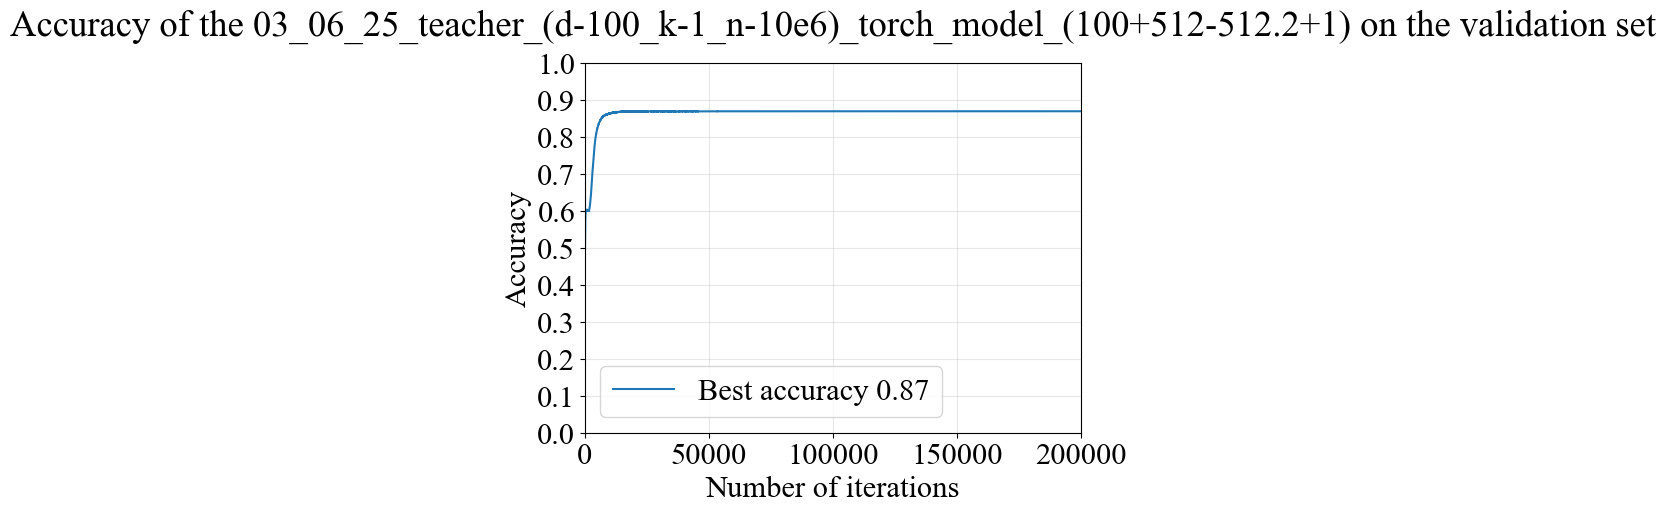

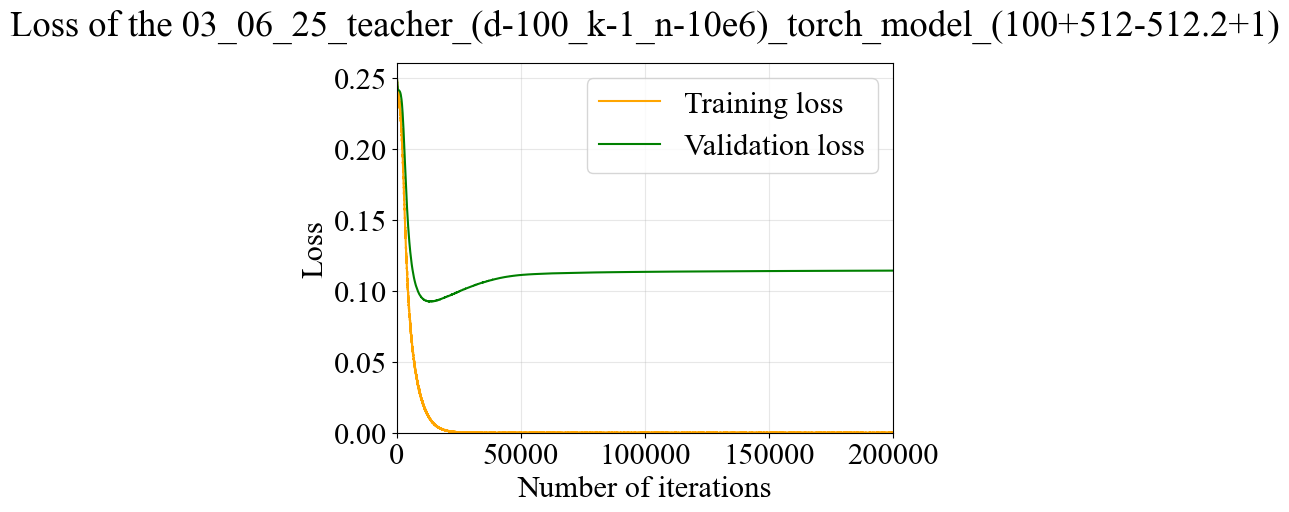

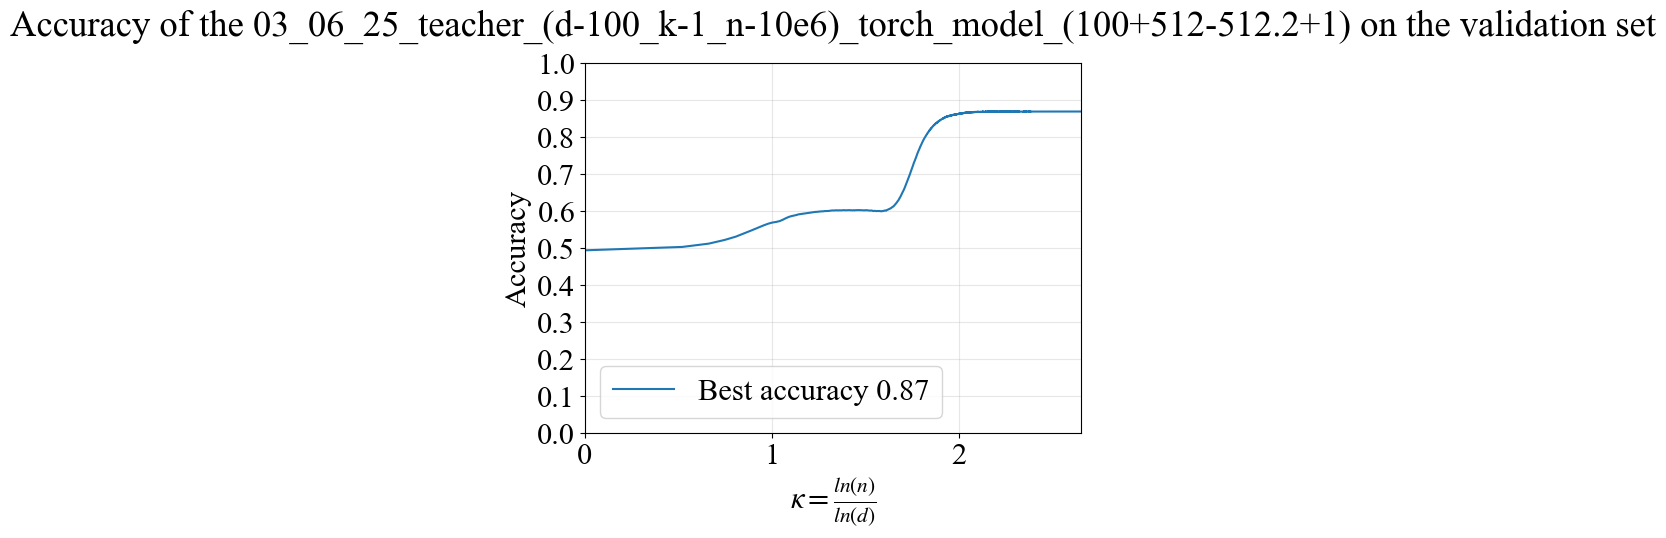

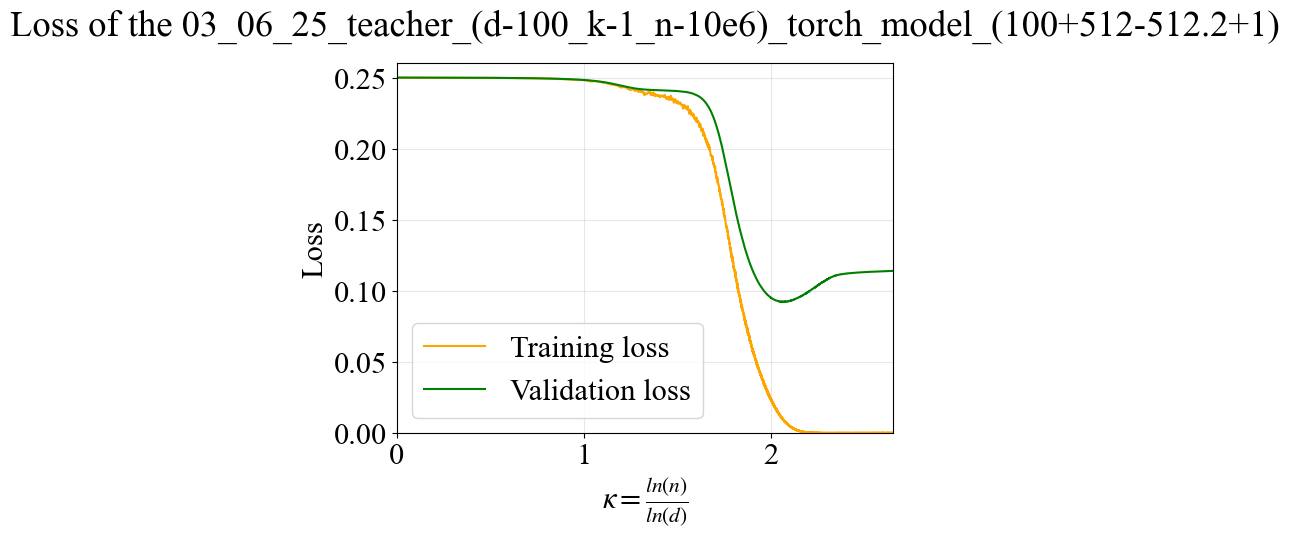

In [26]:
save = True
date = "03_06_25"

if save :
    # Save the model
    model = torch_model
    model_name = date + '_teacher_(d-100_k-1_n-10e6)_torch_model_(100+512.3+1)' #
    save_path = "Classifiers/" + date + '/' + model_name + '/'
    os.makedirs(save_path, exist_ok=True)
    # torch.save(model , save_path + model_name + ".pt")


    # Save Architecture
    with open(save_path + "architecture.txt", "w", encoding="utf-8") as f:
        for key, value in model.architecture.items():
            f.write(f"{key} = {value}\n")

    # Save performances of the model
    os.makedirs(save_path + "figures/", exist_ok=True) 
    # Plot accuracy = f(n)
    plt.plot(np.linspace(0, len(model.accuracy_trajectory)*model.observation_rate, len(model.accuracy_trajectory)), model.accuracy_trajectory, label = "Best accuracy " + str(np.round(np.max(model.accuracy_trajectory), 2)))
    plt.xlim(0, len(model.accuracy_trajectory)*model.observation_rate)
    plt.ylim(0,1)
    plt.yticks(np.linspace(0,1,11))
    plt.xlabel("Number of iterations")  
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.title("Accuracy of the " + model_name + " on the validation set", pad = 20)
    plt.legend()
    plt.savefig(save_path + "figures/accuracy_of_" + model_name + ".png", bbox_inches='tight')
    plt.savefig(save_path + "figures/accuracy_of_" + model_name + ".svg", bbox_inches='tight')
    data = np.column_stack((np.linspace(0, len(model.accuracy_trajectory)*model.observation_rate, len(model.accuracy_trajectory)), model.accuracy_trajectory)) 
    np.savetxt(save_path +"figures/accuracy_of_" + model_name + ".txt", data, delimiter =",", header="n,accuracy")
    plt.show() 
    
    # Plot training and validation loss = f(n)
    plt.plot(np.linspace(0,len(model.training_loss_trajectory)*model.observation_rate, len(model.training_loss_trajectory)), model.training_loss_trajectory, label = "Training loss", color = "orange")
    plt.plot(np.linspace(0,len(model.validation_loss_trajectory)*model.observation_rate, len(model.validation_loss_trajectory)), model.validation_loss_trajectory, label="Validation loss", color = "green")
    plt.xlim(0, len(model.training_loss_trajectory)*model.observation_rate)
    plt.ylim(0, np.max([np.nan_to_num(model.training_loss_trajectory,nan=0), np.nan_to_num(model.validation_loss_trajectory, nan=0)])+0.01)
    plt.xlabel("Number of iterations")  
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.title("Loss of the " + model_name, pad = 20)
    plt.legend()
    plt.savefig(save_path + "figures/loss_of_" + model_name + ".png", bbox_inches='tight')
    plt.savefig(save_path + "figures/loss_of_" + model_name + ".svg", bbox_inches='tight')
    data = np.column_stack((np.linspace(0,len(model.training_loss_trajectory)*model.observation_rate, len(model.training_loss_trajectory)), model.training_loss_trajectory))
    np.savetxt(save_path + "figures/training_loss_of_" + model_name + ".txt", data, delimiter=",", header="n, training_loss")
    data = np.column_stack((np.linspace(0,len(model.validation_loss_trajectory)*model.observation_rate, len(model.validation_loss_trajectory)), model.validation_loss_trajectory))
    np.savetxt(save_path + "figures/validation_loss_of_" + model_name + ".txt", data, delimiter=",", header="n, validation_loss")
    plt.show()
    
    # Plot accuracy = f(kappa)
    kappa = [np.log(n)/np.log(model.input_dimension) for n in np.linspace(1, len(model.accuracy_trajectory)*model.observation_rate+1, len(model.accuracy_trajectory))]
    plt.plot(kappa, model.accuracy_trajectory, label = "Best accuracy " + str(np.round(np.max(model.accuracy_trajectory), 2)))
    plt.xlim(0, np.max(kappa))
    plt.ylim(0,1)
    plt.yticks(np.linspace(0,1,11))
    plt.xlabel(r"$\kappa  = \frac{ln(n)}{ln(d)}$")  
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.title("Accuracy of the " + model_name + " on the validation set", pad = 20)
    plt.legend()
    plt.savefig(save_path + "figures/kappa_accuracy_of_" + model_name + ".png", bbox_inches='tight')
    plt.savefig(save_path + "figures/kappa_accuracy_of_" + model_name + ".svg", bbox_inches='tight')
    data = np.column_stack((kappa, model.accuracy_trajectory))
    np.savetxt(save_path + "figures/kappa_accuracy_of_" + model_name + ".txt", data, delimiter=",", header="kappa, accuracy")
    plt.show()
    
    # Plot training and validation loss
    kappa = [np.log(n)/np.log(model.input_dimension) for n in np.linspace(1, len(model.training_loss_trajectory)*model.observation_rate, len(model.training_loss_trajectory))]
    plt.plot(kappa, model.training_loss_trajectory, label = "Training loss", color = "orange")
    plt.plot(kappa, model.validation_loss_trajectory, label = "Validation loss", color = "green")
    plt.xlim(0, np.max(kappa))
    plt.ylim(0, np.max([np.nan_to_num(model.training_loss_trajectory,nan=0), np.nan_to_num(model.validation_loss_trajectory, nan=0)])+0.01)
    plt.xlabel(r"$\kappa  = \frac{ln(n)}{ln(d)}$")  
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.title("Loss of the " + model_name, pad = 20)
    plt.legend()
    plt.savefig(save_path + "figures/kappa_loss_of_" + model_name + ".png", bbox_inches='tight')
    plt.savefig(save_path + "figures/kappa_loss_of_" + model_name + ".svg", bbox_inches='tight')
    data_training = np.column_stack((kappa, model.training_loss_trajectory))
    np.savetxt(save_path + "figures/kappa_training_loss_of_" + model_name + ".txt", data_training, delimiter=",", header="kappa, training_loss")
    data_validation = np.column_stack((kappa, model.validation_loss_trajectory))
    np.savetxt(save_path + "figures/kappa_validation_loss_of_" + model_name + ".txt", data_validation, delimiter=",", header="kappa, validation_loss")
    plt.show()
    
    np.savetxt(save_path + "fraction_minibatch_" + model_name + ".txt", [model.fraction_minibatch], delimiter=",", header="fraction_minibatch")


    if model.last_layer_fine_tuned_accuracy_trajectory != [] :
        data_training_loss = np.column_stack((np.linspace(0,len(model.last_layer_fine_tuned_training_loss_trajectory)*model.fine_tuning_interval,len(model.last_layer_fine_tuned_training_loss_trajectory)), model.last_layer_fine_tuned_training_loss_trajectory))
        np.savetxt(save_path + 'figures/training_loss_of_' + model_name + '_last_layer_fine_tuned.txt', data_training_loss, delimiter=",", header="Iterations, training_loss")
        data_validation_loss = np.column_stack((np.linspace(0,len(model.last_layer_fine_tuned_validation_loss_trajectory)*model.fine_tuning_interval,len(model.last_layer_fine_tuned_validation_loss_trajectory)), model.last_layer_fine_tuned_validation_loss_trajectory))
        np.savetxt(save_path + 'figures/validation_loss_of_' + model_name + '_last_layer_fine_tuned.txt', data_validation_loss, delimiter=",", header="Iterations, validation_loss")
        data_accuracy = np.column_stack((np.linspace(0,len(model.last_layer_fine_tuned_accuracy_trajectory)*model.fine_tuning_interval,len(model.last_layer_fine_tuned_accuracy_trajectory)), model.last_layer_fine_tuned_accuracy_trajectory))
        np.savetxt(save_path + 'figures/accuracy_of_' + model_name + '_last_layer_fine_tuned.txt', data_accuracy, delimiter=",", header="Iterations, accuracy")
        
    if model.best_1st_layer is not None :
        torch.save(model.best_1st_layer, save_path + model_name + '_first_layer_weight_bias.pt' )

    if model.first_layer_trajectory is not None :
        torch.save(model.first_layer_trajectory, save_path + model_name + '_first_layer_weight_bias_trajectory.pt' )
    
    if model.second_layer_trajectory is not None :
        torch.save(model.second_layer_trajectory, save_path + model_name + '_second_layer_weight_bias_trajectory.pt' )

    if model.W1_stars is not None :
        torch.save(model.W1_stars, save_path + model_name + '_teacher_model.pt' )
    
    torch.save(model.training_inputs, save_path + 'training_set.pt')
    torch.save(model.validation_inputs, save_path + 'validation_set.pt' ) 
else:
    print("No save")
